# BetaDrift + CorrelBreak: figuring out if this actually works

This is the notebook where I test everything I built in `betadrift.py`
and `correlbreak/correlbreak.py` against real market data, pulled live
through `yfinance`. I didn't want to just trust that my code was doing
what I intended — I wanted to actually *see* it. If I'm claiming a model
detects market stress, I should be able to point at a chart and go
"yes, that's clearly the 2020 crash," not just take my own word for it.

So that's what this notebook is: I build a chart, I write down what I
expect to see before I look at the output, and then I check whether
reality agrees with me. A few times it didn't, and those moments turned
out to be the most useful part of this whole project — I'll flag them as
they come up instead of quietly fixing them and pretending I got it
right the first time.

**How this is organized:**
1. Setup — load the data I already cached, pull in my two modules.
2. **CorrelBreak** — the part that tries to detect what "regime" the
  market is in (calm, transitioning, or stressed). 3 figures.
3. **BetaDrift** — the part that measures a portfolio's actual risk
  exposure and tells you when to rebalance. 7 figures.

I tried to write this the way I'd want to read it if I were seeing this
project for the first time: what I was trying to do, what I actually
found, and why it matters.

## Setup

Nothing conceptually interesting happens here — I'm just loading the
return data I already pulled and cached (`data/returns.csv`), setting up
a dark plot theme so all ten figures look consistent, and defining a
color convention I use everywhere: green/amber/red for
Calm/Transition/Stress, and a fixed color per factor so the same factor
always looks the same color across every chart in this notebook. Small
thing, but it made comparing figures across different sections much
easier once I had it.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('.'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Patch
from sklearn.covariance import LedoitWolf

import betadrift as bd
import correlbreak as cb

OUT = 'outputs'
os.makedirs(OUT, exist_ok=True)

STYLE = {
    'figure.facecolor': '#0f1117',
    'axes.facecolor':   '#1a1d27',
    'axes.edgecolor':   '#2e3147',
    'axes.labelcolor':  '#c8ccd8',
    'xtick.color':      '#7a7f96',
    'ytick.color':      '#7a7f96',
    'text.color':       '#c8ccd8',
    'grid.color':       '#2e3147',
    'grid.linewidth':   0.6,
    'axes.grid':        True,
    'legend.facecolor': '#1a1d27',
    'legend.edgecolor': '#2e3147',
    'font.family':      'monospace',
}
plt.rcParams.update(STYLE)

REGIME_COLORS = {0: '#34c5a0', 1: '#f5a623', 2: '#e85d75'}
REGIME_NAMES  = {0: 'Calm', 1: 'Transition', 2: 'Stress'}
FACTOR_COLORS = {
    'MKT': '#4f8ef7', 'DUR': '#34c5a0', 'CRED': '#f5a623',
    'MOM': '#9b7fe8', 'VOL': '#e85d75', 'SMB': '#4ecdc4',
    'INTL': '#f7b731', 'CMDTY': '#fd9644', 'IDIO': '#7a7f96',
}

returns = pd.read_csv(os.path.join('data', 'returns.csv'),
                      index_col=0, parse_dates=True)
dollar_vol = pd.read_csv(os.path.join('data', 'volumes.csv'),
                         index_col=0, parse_dates=True)
portfolio = bd.load_portfolio(os.path.join('data', 'portfolio.json'))

print('returns:', returns.shape, returns.index.min(), '->', returns.index.max())
print('universe:', list(returns.columns))
print('portfolio tickers:', list(portfolio['weights'].keys()))

returns: (3893, 12) 2011-02-02 00:00:00 -> 2026-07-28 00:00:00
universe: ['EEM', 'EFA', 'GLD', 'HYG', 'IEF', 'IWM', 'QQQ', 'SPY', 'TLT', 'USO', 'VIXY', 'VNQ']
portfolio tickers: ['SPY', 'QQQ', 'EFA', 'EEM', 'TLT', 'IEF', 'HYG', 'GLD', 'VNQ']


# Part 1 — CorrelBreak: can I actually detect a market regime?

## Fitting the HMM

The idea behind CorrelBreak is something I kept running into while
reading about portfolio construction: textbook diversification assumes
assets that don't move together will *keep* not moving together. That's
just not true during a crisis — everything starts correlating at once,
right when you need diversification the most. I wanted to see if I could
actually detect that shift happening, not just talk about it
abstractly.

My approach: at every trading day, compute 5 numbers that describe the
"shape" of the market that day (average correlation across a cluster of
assets, how spread out those correlations are, realized volatility,
cross-sectional dispersion, and the SPY-TLT correlation — more on that
last one in a second). Then feed that 5-number sequence into a Gaussian
Hidden Markov Model with 3 hidden states, and let it figure out where
the boundaries between "calm," "transitioning," and "stressed" actually
are, instead of me hand-picking thresholds.

I chose an HMM specifically because regimes aren't just about where the
market is *today* — they're sticky. If yesterday was a stress day, today
is probably still a stress day. An HMM's transition matrix captures
exactly that kind of persistence, which a simpler day-by-day classifier
wouldn't.

**Honest confession — my first version of this didn't work.** I
originally computed "average correlation" across all 12 assets in my
universe, the way you'd naively expect. It completely failed to separate
calm from stressed days. It took me a while to figure out why: I
deliberately included VIXY and Treasuries (TLT/IEF) *because* they're
supposed to be negatively correlated with equities — that's the whole
point of a hedge. But that negative correlation gets even *more* negative
during a panic (flight to quality), which means it was canceling out the
positive equity-equity correlation in my simple average. I was
accidentally computing something close to zero no matter what regime the
market was actually in. Once I restricted the correlation feature to a
cluster of assets that are normally positively correlated with each
other (equities, high yield credit, REITs — the stuff that actually
panics together), the signal showed up clearly. That's documented in
`RISK_CLUSTER` inside `correlbreak.py` if you want the actual numbers I
used to convince myself this was real and not a fluke.

**What I'm checking below:** that the model actually uses all 3 states
(not just collapsing to 2), and that it agrees with dates I already know
the answer to — 2017 should read as calm, and the 2020 COVID crash and
the 2011 European debt crisis should both read as stress. If it can't
get the obvious cases right, there's no point trusting it on the
ambiguous ones.

In [2]:
result = cb.fit_hmm(returns)
dates = result['dates']
labels = pd.Series(result['labels'], index=dates)
probs = pd.DataFrame(result['probs'], index=dates,
                     columns=['Calm', 'Transition', 'Stress'])
feat_names = ['avg_corr', 'std_corr', 'avg_vol', 'cs_disp', 'spy_tlt_corr']
features = pd.DataFrame(result['features'], index=dates, columns=feat_names)

counts = labels.value_counts().sort_index()
print('Regime day counts:', counts.to_dict())
print('Regime day fractions:', (counts / counts.sum()).round(3).to_dict())
print('Log-likelihood:', round(result['log_likelihood'], 1))

for ref_date, ref_label in [('2017-06-15', 'Calm'), ('2020-03-20', 'Stress'), ('2011-08-15', 'Stress')]:
    pos = dates.searchsorted(pd.Timestamp(ref_date))
    print(f'{ref_date}: predicted {REGIME_NAMES[labels.iloc[pos]]} (expected {ref_label})')

Regime day counts: {0: 1810, 1: 1523, 2: 498}
Regime day fractions: {0: 0.472, 1: 0.398, 2: 0.13}
Log-likelihood: -18786.3
2017-06-15: predicted Calm (expected Calm)
2020-03-20: predicted Stress (expected Stress)
2011-08-15: predicted Stress (expected Stress)


## Figure CB-1: does the regime timeline actually line up with real history?

This is the first real gut-check for the whole model. I'm plotting four
things stacked on top of each other: SPY/TLT/GLD prices with my detected
regime shaded behind them, the correlation feature colored by regime,
the SPY-TLT relationship specifically (shaded red when it's gone
positive — meaning bonds and stocks are falling together, which is the
signature of 2022 — and green when it's negative and doing its job as a
hedge), and finally just the raw regime timeline by itself so I can
compare it against events I actually remember happening.

I know roughly when the real crises were — 2011 (European debt crisis),
2018 (that quick volatility spike), 2020 (COVID), 2022 (the rate-hike
selloff). So my bar for this figure is simple: if the red bands in the
bottom panel don't line up with those dates, the model isn't detecting
anything real, it's just detecting noise. I wanted to see that for
myself before trusting any of the later, more complicated analysis.

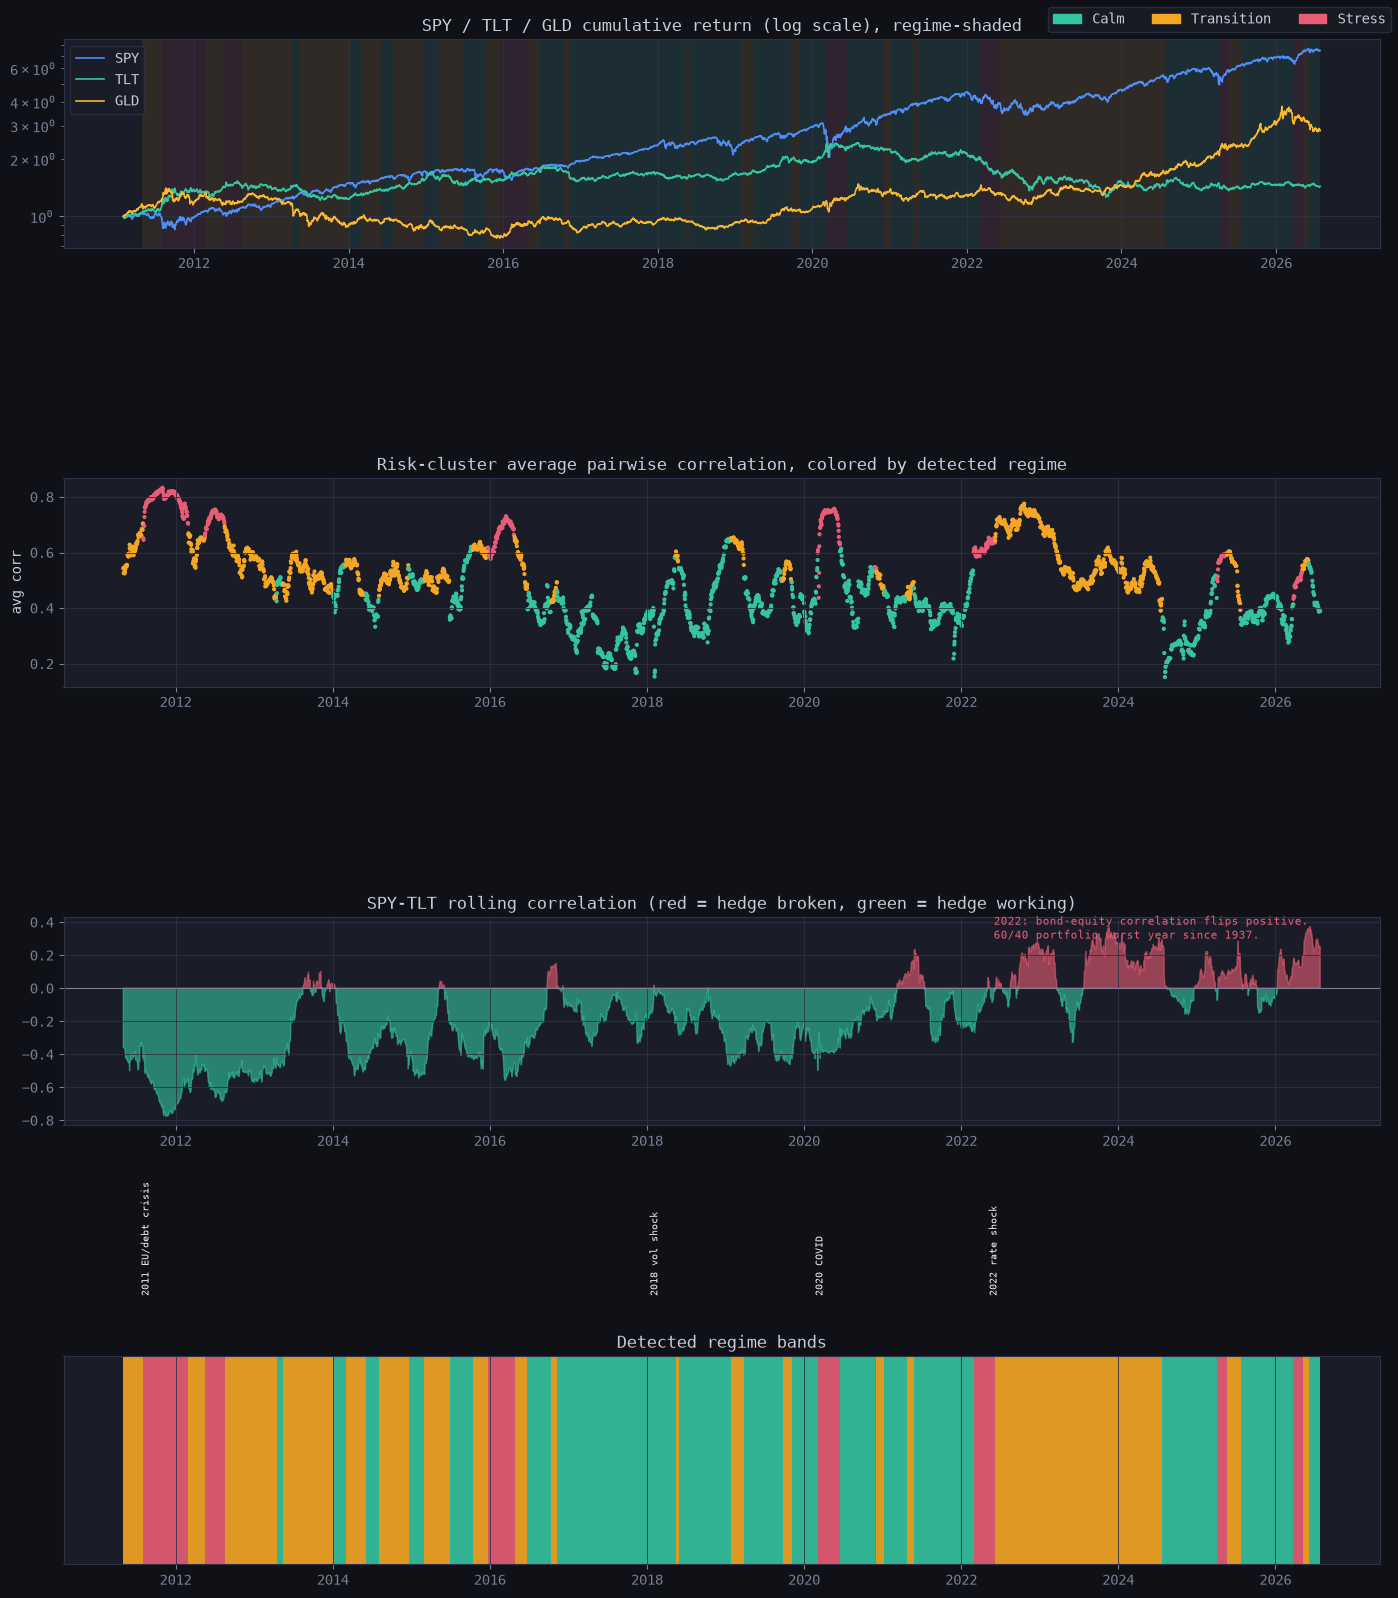

In [3]:
fig, axes = plt.subplots(4, 1, figsize=(14, 16), sharex=False)

cum_ret = np.exp(returns[['SPY', 'TLT', 'GLD']].cumsum())
ax = axes[0]
for col, color in zip(['SPY', 'TLT', 'GLD'], ['#4f8ef7', '#34c5a0', '#f7b731']):
    ax.plot(cum_ret.index, cum_ret[col], label=col, color=color, linewidth=1.2)
ax.set_yscale('log')
for i in range(len(dates) - 1):
    ax.axvspan(dates[i], dates[i+1], color=REGIME_COLORS[labels.iloc[i]], alpha=0.10, linewidth=0)
ax.set_title('SPY / TLT / GLD cumulative return (log scale), regime-shaded')
ax.legend(loc='upper left')

ax = axes[1]
ax.scatter(dates, features['avg_corr'], c=[REGIME_COLORS[l] for l in labels], s=4)
ax.set_title('Risk-cluster average pairwise correlation, colored by detected regime')
ax.set_ylabel('avg corr')

ax = axes[2]
spy_tlt = features['spy_tlt_corr']
ax.fill_between(dates, spy_tlt, 0, where=(spy_tlt >= 0), color='#e85d75', alpha=0.6, interpolate=True)
ax.fill_between(dates, spy_tlt, 0, where=(spy_tlt < 0), color='#34c5a0', alpha=0.6, interpolate=True)
ax.axhline(0, color='#7a7f96', linewidth=0.8)
ax.set_title('SPY-TLT rolling correlation (red = hedge broken, green = hedge working)')
ax.annotate('2022: bond-equity correlation flips positive.\n60/40 portfolio worst year since 1937.',
           xy=(pd.Timestamp('2022-06-01'), 0.3), fontsize=8, color='#e85d75')

ax = axes[3]
for i in range(len(dates) - 1):
    ax.axvspan(dates[i], dates[i+1], color=REGIME_COLORS[labels.iloc[i]], alpha=0.9, linewidth=0)
ax.set_yticks([])
ax.set_title('Detected regime bands')
crisis_notes = [('2011-08-15', '2011 EU/debt crisis'), ('2018-02-05', '2018 vol shock'),
               ('2020-03-15', '2020 COVID'), ('2022-06-01', '2022 rate shock')]
for d, label in crisis_notes:
    ts = pd.Timestamp(d)
    if dates.min() <= ts <= dates.max():
        ax.annotate(label, xy=(ts, 0.5), xytext=(ts, 1.3), fontsize=7, color='#e8eaf0',
                   rotation=90, ha='center')

handles = [Patch(color=c, label=REGIME_NAMES[k]) for k, c in REGIME_COLORS.items()]
fig.legend(handles=handles, loc='upper right', ncol=3)
plt.tight_layout()
plt.savefig(os.path.join(OUT, 'fig_cb1_regime_timeline.png'), dpi=110, facecolor=fig.get_facecolor())
plt.show()

## Figure CB-2: is the model actually learning structure, or just memorizing dates?

Figure CB-1 checked whether the regime labels line up with history I
already knew. This one is a different question: is the model separating
the underlying *data* in a sensible way, independent of whether I
happen to recognize the dates? If I showed these six panels to someone
who'd never heard of a 2020 crash, would they still be able to tell that
something structurally different is happening in the "stress" cluster?

The one I was most nervous about is the top-right scatter plot —
correlation vs. volatility, colored by the regime the model assigned.
If the three colors are all mixed together in one blob, the model isn't
really finding 3 distinct states, it's just kind of guessing. If they
form three separate clusters, that's actual evidence the 5 features I
engineered contain real signal.

The two correlation heatmaps in the middle (same 12 assets, one from a
calm day in 2017, one from the worst of the COVID crash) are the
clearest visual argument I have for the whole thesis of this project:
diversification is not a fixed property of a portfolio, it depends on
what regime you're in. I want these two heatmaps to look obviously
different from each other — same assets, completely different
correlation structure.

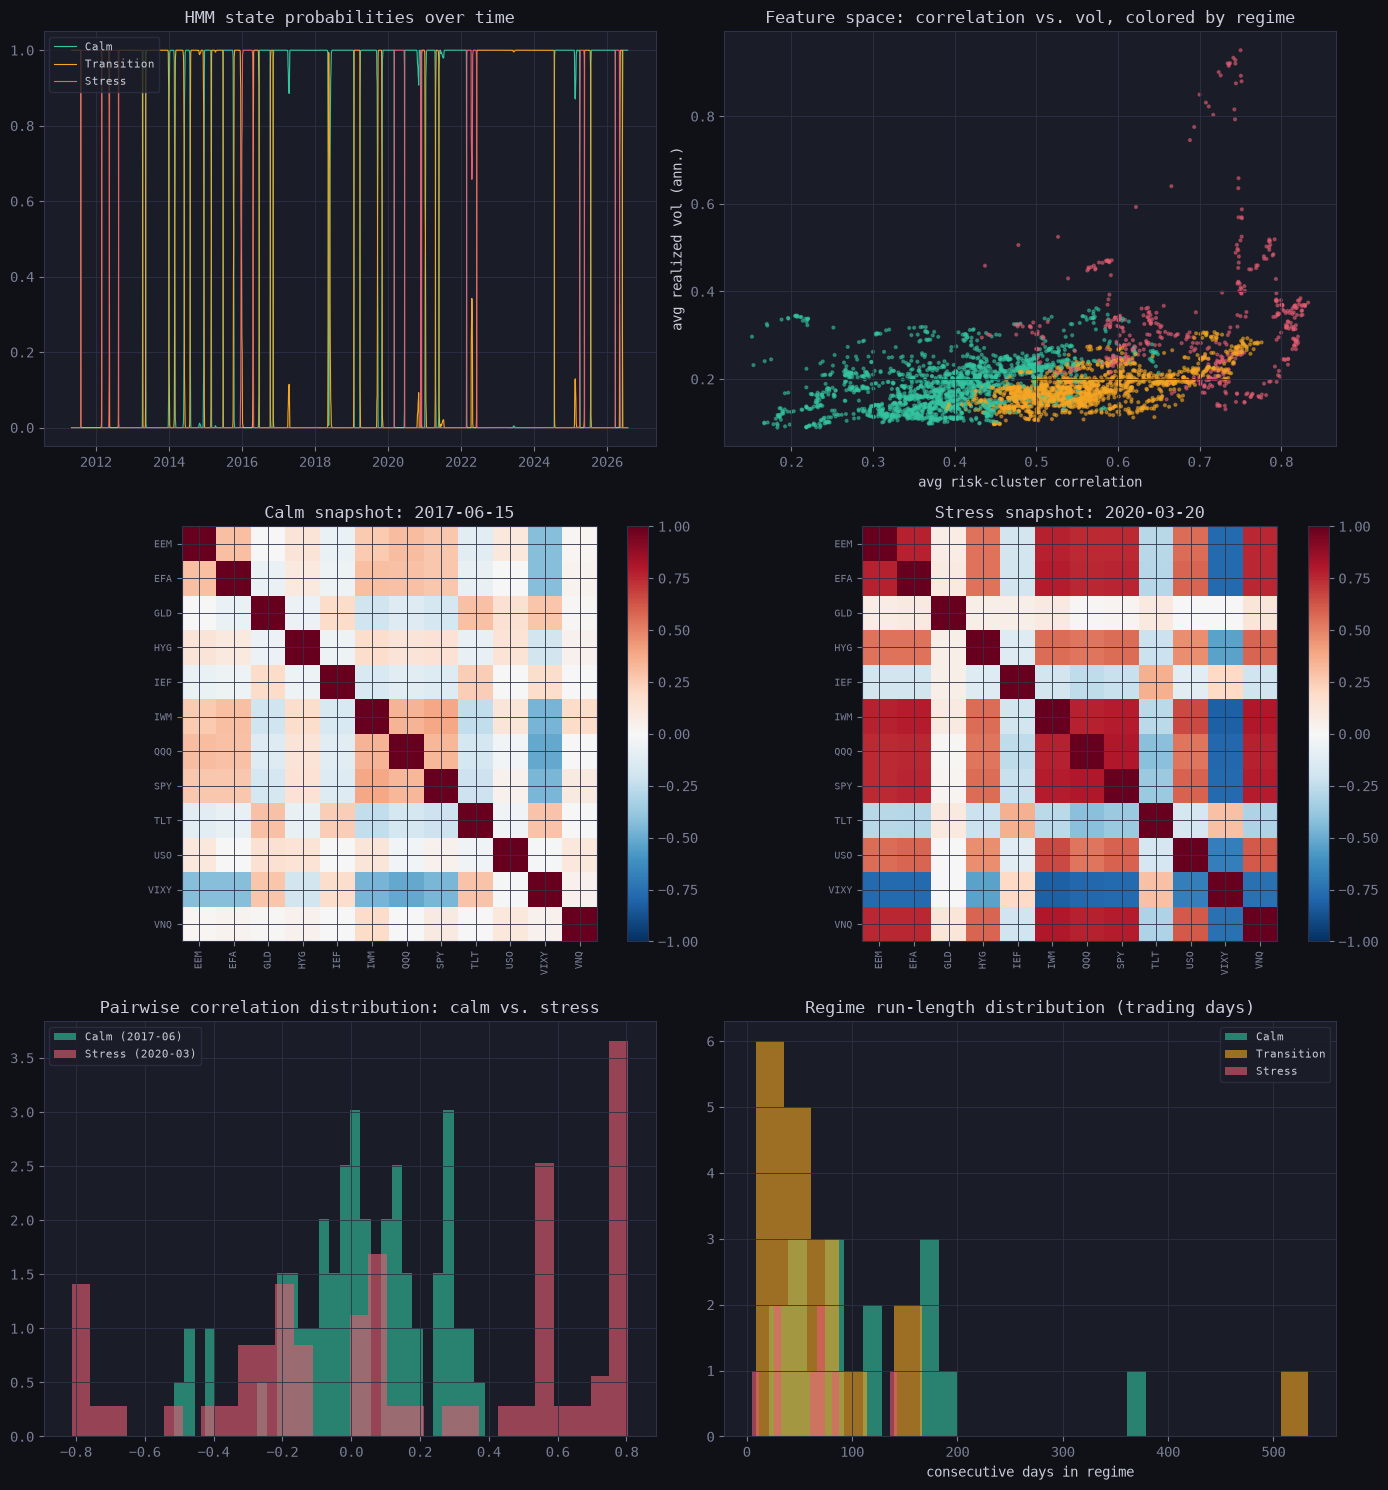

In [4]:
fig, axes = plt.subplots(3, 2, figsize=(14, 15))

ax = axes[0, 0]
for i, name in enumerate(['Calm', 'Transition', 'Stress']):
    ax.plot(dates, probs[name], label=name, color=REGIME_COLORS[i], linewidth=0.8)
ax.set_title('HMM state probabilities over time')
ax.legend(loc='upper left', fontsize=8)

ax = axes[0, 1]
ax.scatter(features['avg_corr'], features['avg_vol'], c=[REGIME_COLORS[l] for l in labels], s=4, alpha=0.5)
ax.set_xlabel('avg risk-cluster correlation')
ax.set_ylabel('avg realized vol (ann.)')
ax.set_title('Feature space: correlation vs. vol, colored by regime')

cov_data = result['cov_data']
cov_dates = cov_data['dates']

def corr_snapshot(date_str):
    pos = min(cov_dates.searchsorted(pd.Timestamp(date_str)), len(cov_dates) - 1)
    return cb.cov_to_corr(cov_data['shrunk'][pos]), cov_dates[pos]

calm_corr, calm_date = corr_snapshot('2017-06-15')
stress_corr, stress_date = corr_snapshot('2020-03-20')
cols = list(returns.columns)

ax = axes[1, 0]
im = ax.imshow(calm_corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(cols))); ax.set_xticklabels(cols, rotation=90, fontsize=7)
ax.set_yticks(range(len(cols))); ax.set_yticklabels(cols, fontsize=7)
ax.set_title(f'Calm snapshot: {calm_date.date()}')
plt.colorbar(im, ax=ax, fraction=0.046)

ax = axes[1, 1]
im = ax.imshow(stress_corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(cols))); ax.set_xticklabels(cols, rotation=90, fontsize=7)
ax.set_yticks(range(len(cols))); ax.set_yticklabels(cols, fontsize=7)
ax.set_title(f'Stress snapshot: {stress_date.date()}')
plt.colorbar(im, ax=ax, fraction=0.046)

ax = axes[2, 0]
mask = np.triu(np.ones_like(calm_corr, dtype=bool), k=1)
ax.hist(calm_corr[mask], bins=30, alpha=0.6, color=REGIME_COLORS[0], label='Calm (2017-06)', density=True)
ax.hist(stress_corr[mask], bins=30, alpha=0.6, color=REGIME_COLORS[2], label='Stress (2020-03)', density=True)
ax.set_title('Pairwise correlation distribution: calm vs. stress')
ax.legend(fontsize=8)

ax = axes[2, 1]
run_id = (labels != labels.shift()).cumsum()
run_lengths = labels.groupby(run_id).agg(['first', 'size'])
for i, name in enumerate(['Calm', 'Transition', 'Stress']):
    lengths = run_lengths[run_lengths['first'] == i]['size']
    if len(lengths):
        ax.hist(lengths, bins=20, alpha=0.6, color=REGIME_COLORS[i], label=name)
ax.set_title('Regime run-length distribution (trading days)')
ax.set_xlabel('consecutive days in regime')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(OUT, 'fig_cb2_hmm_diagnostics.png'), dpi=110, facecolor=fig.get_facecolor())
plt.show()

## Figure CB-3: putting a number on "diversification disappears in a crisis," and then testing my own assumption

The heatmaps in the last figure convinced me visually that correlation
structure changes a lot between calm and stress. But "looks different"
isn't a number I can compare across dates, so I wanted a single metric
that captures the same idea. That's where I learned about **PCA** as a
diversification measure, which I hadn't really thought about before
this project: if you run PCA on the correlation matrix and the first
principal component explains a huge share of the variance, that means
your 12 supposedly-different assets are really behaving like one big
bet. If the variance is spread across many components, you actually have
independent sources of risk. This ratio — how much the top component
explains — is called the **absorption ratio**, and I use it here as a
cleaner, single-number version of "how correlated is everything right
now."

Once I had that, I got curious about a second question: does knowing the
regime actually help you make better decisions, or is this just an
interesting academic exercise? So I built a small walk-forward test —
three simple strategies on the same 4-asset basket (SPY/TLT/GLD/HYG):
just holding them equally, a "static" Markowitz minimum-variance
portfolio (computed once on the first year of data and never touched
again — this is what a lot of naive quant approaches actually do), and a
simplified strategy that shifts toward TLT/GLD whenever CorrelBreak says
we're in Transition or Stress.

Going in, I assumed the regime-switching strategy would just win, every
time, in every crisis — that was basically my hypothesis for why this
whole project is useful. I want to be upfront that I was wrong about
that, in an interesting way. I'll show you the actual result below
instead of quietly adjusting the writeup to sound like I predicted it.

One honest limitation before I get there: this backtest uses regime
labels from an HMM trained on the *entire* history, including the period
I'm testing on. That's look-ahead bias — a real trading system would
have to refit the model using only data it actually had at the time.
So take this as a demonstration of the mechanism, not a validated
trading strategy.

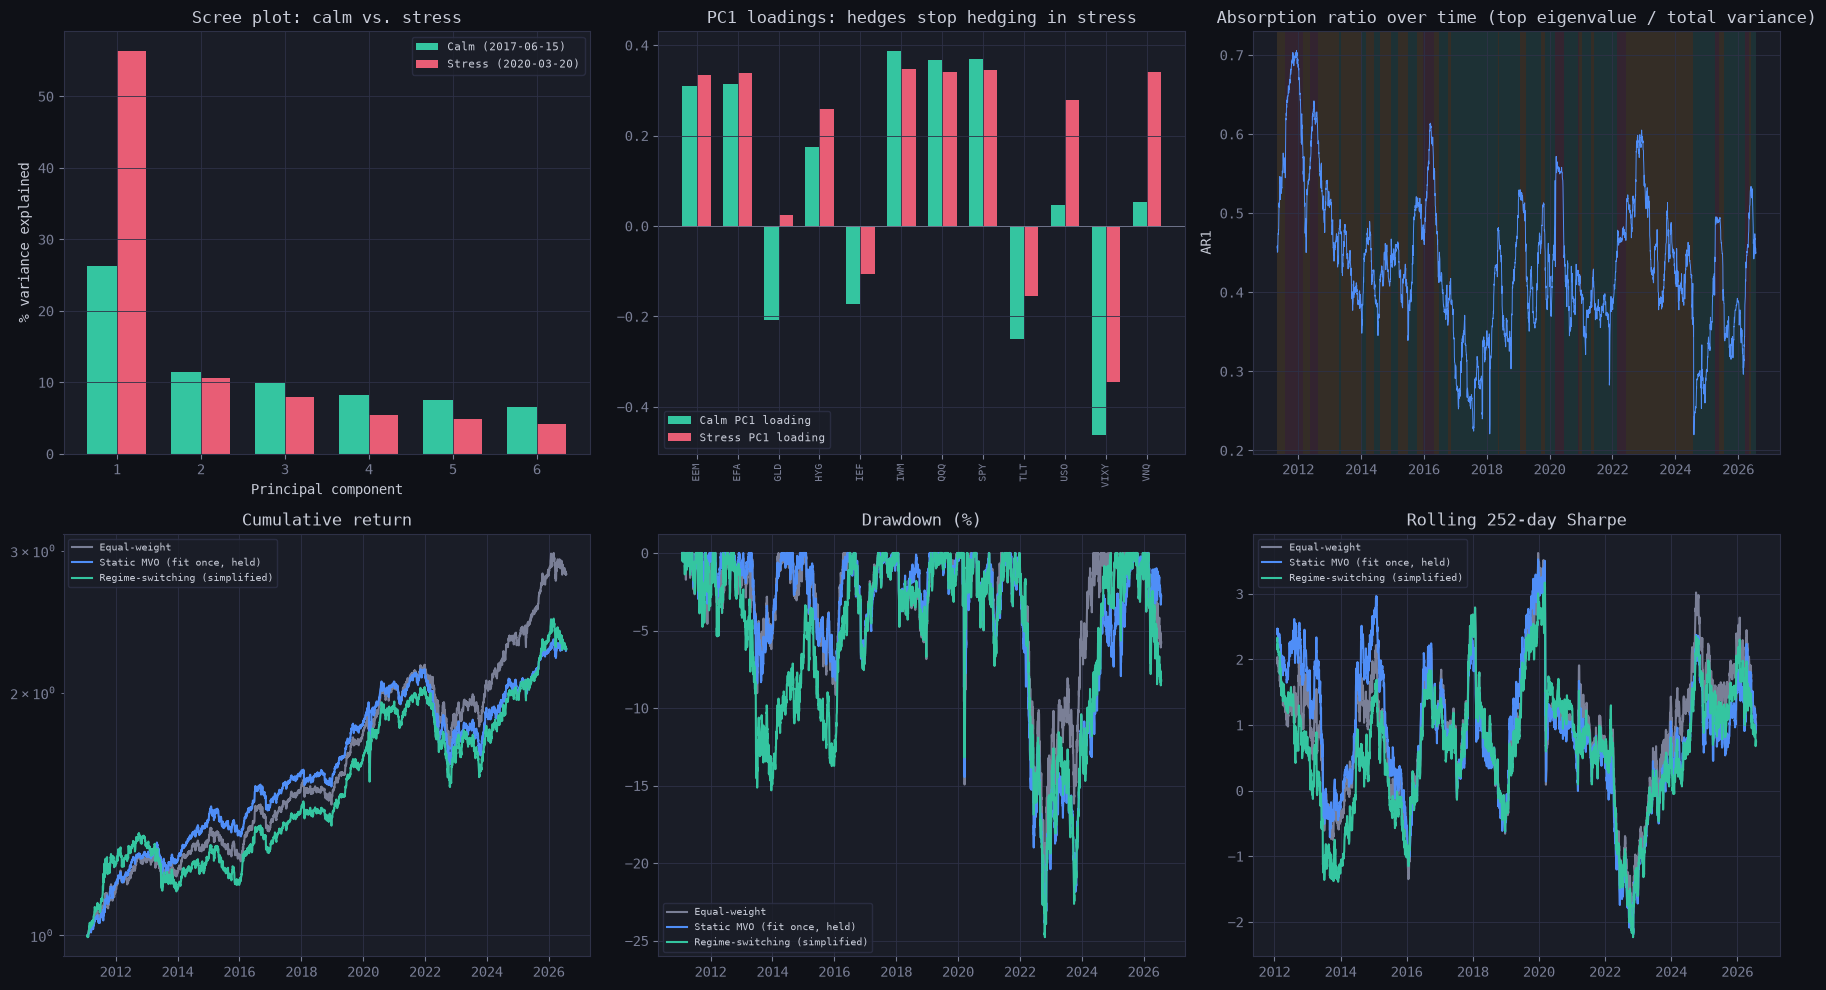

Absorption ratio at key dates:
  2017-06-15: AR1=0.263
  2011-08-15: AR1=0.624
  2020-03-20: AR1=0.563
  2022-06-15: AR1=0.514

Max drawdown by strategy, within each named episode:
  2020 COVID:
    Equal-weight: -14.93%
    Static MVO (fit once, held): -14.45%
    Regime-switching (simplified): -13.19%
  2022 rate shock:
    Equal-weight: -20.55%
    Static MVO (fit once, held): -22.84%
    Regime-switching (simplified): -24.03%


In [5]:
def pca_scree(corr):
    eigvals, eigvecs = np.linalg.eigh(corr)  # ascending order
    order = np.argsort(eigvals)[::-1]
    eigvals, eigvecs = eigvals[order], eigvecs[:, order]
    explained = eigvals / eigvals.sum()
    return explained, eigvecs

calm_explained, calm_eigvecs = pca_scree(calm_corr)
stress_explained, stress_eigvecs = pca_scree(stress_corr)

# Eigenvector sign is arbitrary -- normalize so the SPY loading on PC1 is
# always positive, so "which assets load opposite SPY" is directly readable.
spy_pos = cols.index('SPY')
if calm_eigvecs[spy_pos, 0] < 0:
    calm_eigvecs[:, 0] *= -1
if stress_eigvecs[spy_pos, 0] < 0:
    stress_eigvecs[:, 0] *= -1

n_pc = 6
absorption_ratio = pd.Series(
    [np.linalg.eigvalsh(cb.cov_to_corr(c))[-1] / np.linalg.eigvalsh(cb.cov_to_corr(c)).sum()
     for c in cov_data['shrunk']],
    index=cov_dates)

basket = ['SPY', 'TLT', 'GLD', 'HYG']
equal_w = pd.Series(0.25, index=basket)

mvo_window = returns[basket].iloc[:252]
mvo_cov = LedoitWolf().fit(mvo_window).covariance_
inv_cov = np.linalg.inv(mvo_cov)
ones = np.ones(len(basket))
mvo_raw = inv_cov @ ones / (ones @ inv_cov @ ones)
mvo_w = pd.Series(np.clip(mvo_raw, 0, None), index=basket)
mvo_w = mvo_w / mvo_w.sum()  # long-only global minimum-variance, fit once, static

defensive_w = pd.Series({'SPY': 0.10, 'TLT': 0.45, 'GLD': 0.35, 'HYG': 0.10})
aligned_labels = labels.reindex(returns.index).ffill().bfill()
switch_returns = pd.Series(index=returns.index, dtype=float)
for date in returns.index:
    w = equal_w if aligned_labels.loc[date] == 0 else defensive_w
    switch_returns.loc[date] = returns.loc[date, basket].dot(w)

equal_returns = returns[basket].dot(equal_w)
mvo_returns = returns[basket].dot(mvo_w)

strategies = {
    'Equal-weight': (equal_returns, '#7a7f96'),
    'Static MVO (fit once, held)': (mvo_returns, '#4f8ef7'),
    'Regime-switching (simplified)': (switch_returns, '#34c5a0'),
}

def drawdown(cum):
    return (cum / cum.cummax() - 1) * 100

def rolling_sharpe(ret, window=252):
    return (ret.rolling(window).mean() / ret.rolling(window).std()) * np.sqrt(252)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

ax = axes[0, 0]
x = np.arange(1, n_pc + 1)
w = 0.35
ax.bar(x - w/2, calm_explained[:n_pc] * 100, w, label=f'Calm ({calm_date.date()})', color=REGIME_COLORS[0])
ax.bar(x + w/2, stress_explained[:n_pc] * 100, w, label=f'Stress ({stress_date.date()})', color=REGIME_COLORS[2])
ax.set_xticks(x)
ax.set_xlabel('Principal component')
ax.set_ylabel('% variance explained')
ax.set_title('Scree plot: calm vs. stress')
ax.legend(fontsize=8)

ax = axes[0, 1]
x = np.arange(len(cols))
ax.bar(x - w/2, calm_eigvecs[:, 0], w, label='Calm PC1 loading', color=REGIME_COLORS[0])
ax.bar(x + w/2, stress_eigvecs[:, 0], w, label='Stress PC1 loading', color=REGIME_COLORS[2])
ax.axhline(0, color='#7a7f96', linewidth=0.6)
ax.set_xticks(x); ax.set_xticklabels(cols, rotation=90, fontsize=7)
ax.set_title('PC1 loadings: hedges stop hedging in stress')
ax.legend(fontsize=8)

ax = axes[0, 2]
ax.plot(absorption_ratio.index, absorption_ratio, color='#4f8ef7', linewidth=0.7)
for i in range(len(dates) - 1):
    ax.axvspan(dates[i], dates[i+1], color=REGIME_COLORS[labels.iloc[i]], alpha=0.12, linewidth=0)
ax.set_title('Absorption ratio over time (top eigenvalue / total variance)')
ax.set_ylabel('AR1')

ax = axes[1, 0]
for name, (ret, color) in strategies.items():
    ax.plot(ret.index, np.exp(ret.cumsum()), label=name, color=color)
ax.set_yscale('log')
ax.set_title('Cumulative return')
ax.legend(fontsize=7, loc='upper left')

ax = axes[1, 1]
for name, (ret, color) in strategies.items():
    ax.plot(ret.index, drawdown(np.exp(ret.cumsum())), label=name, color=color)
ax.set_title('Drawdown (%)')
ax.legend(fontsize=7, loc='lower left')

ax = axes[1, 2]
for name, (ret, color) in strategies.items():
    ax.plot(ret.index, rolling_sharpe(ret), label=name, color=color)
ax.set_title('Rolling 252-day Sharpe')
ax.legend(fontsize=7, loc='upper left')

plt.tight_layout()
plt.savefig(os.path.join(OUT, 'fig_cb3_regime_cost.png'), dpi=110, facecolor=fig.get_facecolor())
plt.show()

print('Absorption ratio at key dates:')
for d in ['2017-06-15', '2011-08-15', '2020-03-20', '2022-06-15']:
    pos = min(cov_dates.searchsorted(pd.Timestamp(d)), len(cov_dates) - 1)
    print(f'  {d}: AR1={absorption_ratio.iloc[pos]:.3f}')

def max_drawdown_in_window(ret, start, end):
    cum = np.exp(ret.cumsum())
    window = cum.loc[start:end] / cum.loc[:start].iloc[-1]
    return (window / window.cummax() - 1).min() * 100

print()
print('Max drawdown by strategy, within each named episode:')
for episode, (start, end) in [('2020 COVID', ('2020-01-01', '2020-05-01')),
                              ('2022 rate shock', ('2022-01-01', '2022-12-31'))]:
    print(f'  {episode}:')
    for name, (ret, _) in strategies.items():
        print(f'    {name}: {max_drawdown_in_window(ret, start, end):.2f}%')

### So, was I right? Sort of — and the part I got wrong is more interesting than the part I got right

Here's what actually happened when I ran the numbers, instead of what I
assumed would happen:

- **2020 COVID crash:** regime-switching won. Its drawdown was shallower
 than both equal-weight and the static MVO portfolio. This is exactly
 the scenario I had in my head when I built the strategy — a classic
 flight-to-quality crash, where TLT rallies while equities fall, so
 tilting toward TLT cushions the blow.
- **2022 rate shock:** regime-switching *lost*. Its drawdown was
 actually deeper than either alternative.

I didn't expect that second one at all, and honestly my first reaction
was to assume I had a bug somewhere. But digging into it, it makes
complete sense once I connect it to something I'd already found earlier
in this notebook (Figure 2): TLT's beta to the market came out
*positive* in my data, not negative. 2022 wasn't a stock-panic-buy-bonds
kind of crisis — it was a rate shock, where bonds and stocks fell
together. My "defensive" allocation was overweighting the exact asset
that was causing the damage.

That's the real lesson I'm taking from this, and it's not "the strategy
is broken" — it's that a single fixed "flee to bonds" playbook is
secretly making a bet about *what kind* of crisis is coming. 2020 and
2022 were different kinds of crises, and treating them the same way
only worked for one of them by luck. What I think would actually fix
this is conditioning the defensive move on the *current* factor
structure — what's BetaDrift's DUR and CRED exposure doing right now —
instead of a single static target. Which, conveniently, is exactly what
the rest of this notebook builds toward.

# Part 2 — BetaDrift: what is a portfolio's risk actually made of?

## Building the factor model

CorrelBreak answers "what kind of market are we in." This half of the
project answers a different question that I think matters just as much:
if I hold a portfolio, what is it actually exposed to, and how would I
even describe that in a way that's useful?

The approach I took is a factor model. Instead of thinking about risk
asset-by-asset ("I own some SPY, some TLT..."), I wanted to think about
it in terms of the underlying things that actually move markets — market
direction, interest rates, credit spreads, momentum, volatility, size,
international exposure, commodities. Eight factors, each one built
directly from the ETF returns I already have (so nothing here needs
outside data). Then for every asset, I run a rolling 126-day regression
to estimate how sensitive that asset currently is to each factor — its
beta. I used a *rolling* window on purpose instead of one fixed
regression over all 15 years, because I wanted to capture the fact that
these relationships actually change over time (QQQ's relationship to the
market today is not the same as it was in 2015 — more on that in Figure
2).

Everything else in this half of the notebook builds on these factor
loadings, so this cell is really just laying the foundation.

In [6]:
factor_returns = bd.build_factor_returns(returns)
loadings, idio_residuals, r_squared = bd.rolling_factor_loadings(returns, factor_returns, window=126)
print('factor_returns:', factor_returns.shape, factor_returns.index.min(), '->', factor_returns.index.max())
print('median R^2 per asset:')
print(r_squared.median().round(3))

factor_returns: (3621, 8) 2012-03-02 00:00:00 -> 2026-07-28 00:00:00
median R^2 per asset:
SPY     1.000
QQQ     0.889
IWM     1.000
EFA     1.000
EEM     0.693
TLT     0.965
IEF     0.803
HYG     0.794
GLD     0.528
USO     0.909
VNQ     0.524
VIXY    1.000
dtype: float64


## Figure 1: do the factors behave like their names suggest?

Before trusting any of the more complicated analysis later in this
notebook, I wanted to just look at each factor's own return history and
sanity-check that it's behaving the way its name implies. If my "credit"
factor doesn't dip during 2020, something is wrong with how I built it,
and I'd rather catch that here than three figures later.

Things I'm specifically looking for: MKT trending up over time with
real dips at 2020 and 2022 (it's built directly from SPY, so this should
be obvious). DUR should be positive for most of the sample and then
break down hard in 2022 — that's the story of the rate-hike cycle
hitting long-duration bonds. VOL, being built from VIXY, should trend
down overall (volatility products bleed value over time from contango)
but spike violently in March 2020. If any of these don't show up, I'd
want to go back and check my factor construction before trusting
anything downstream of it.

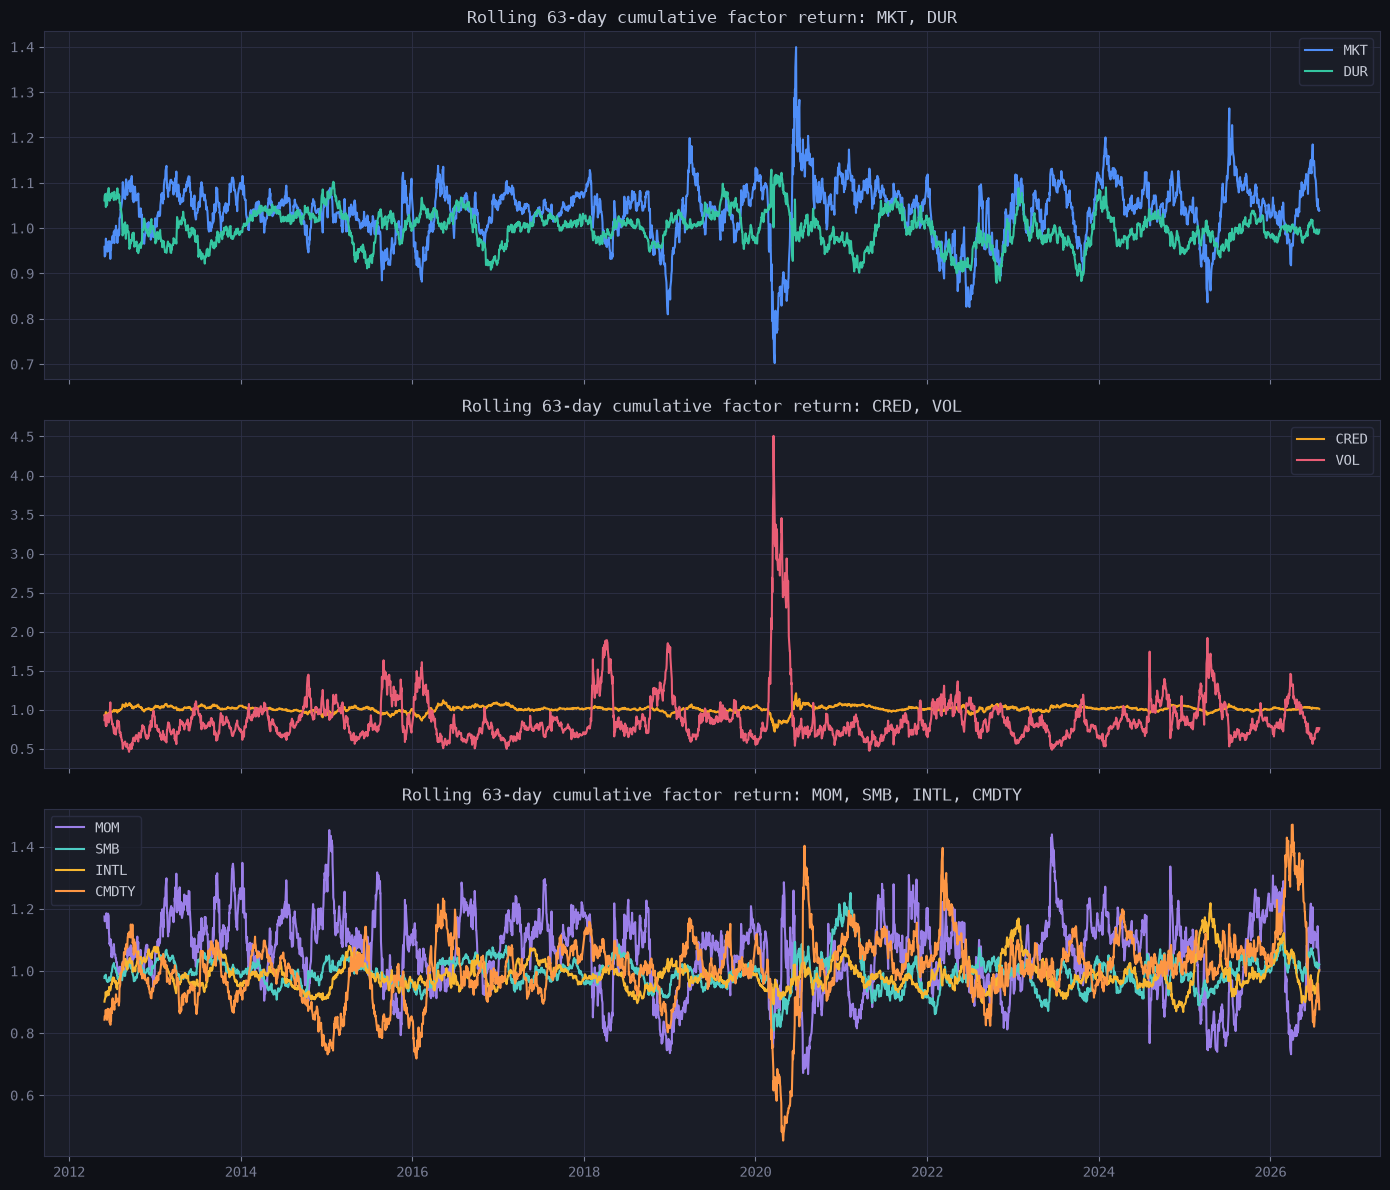

In [7]:
roll_cum = np.exp(factor_returns.rolling(63).sum().dropna())

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

ax = axes[0]
for f in ['MKT', 'DUR']:
    ax.plot(roll_cum.index, roll_cum[f], label=f, color=FACTOR_COLORS[f])
ax.set_title('Rolling 63-day cumulative factor return: MKT, DUR')
ax.legend()

ax = axes[1]
for f in ['CRED', 'VOL']:
    ax.plot(roll_cum.index, roll_cum[f], label=f, color=FACTOR_COLORS[f])
ax.set_title('Rolling 63-day cumulative factor return: CRED, VOL')
ax.legend()

ax = axes[2]
for f in ['MOM', 'SMB', 'INTL', 'CMDTY']:
    ax.plot(roll_cum.index, roll_cum[f], label=f, color=FACTOR_COLORS[f])
ax.set_title('Rolling 63-day cumulative factor return: MOM, SMB, INTL, CMDTY')
ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(OUT, 'fig1_factor_returns.png'), dpi=110, facecolor=fig.get_facecolor())
plt.show()

## Figure 2: how have these betas actually changed over time?

This is the figure that taught me the most while building this project,
partly because it surprised me.

The top-left heatmap is just a snapshot: every asset's current beta to
every factor, all at once. A few of these are going to look suspiciously
perfect — SPY's MKT beta is exactly 1.0, IWM's SMB beta is exactly 1.0,
and so on. At first I thought that might be a bug. It isn't — it's just
algebra catching up with me. I *built* the SMB factor as IWM minus SPY,
so of course regressing IWM against {MKT, SMB, ...} recovers a loading
of exactly 1 on both — there's no other solution. Worth knowing so I
don't mistake my own construction for a "finding."

The genuinely interesting part is the top-right panel: QQQ's market beta
over time. I'd read that QQQ's relationship to the broader market has
gotten stronger as a handful of mega-cap tech/AI names have come to
dominate the index, and I wanted to actually check that instead of just
repeating it. The rolling beta does show a real upward drift into
2023–2024, sitting well above 1.0 — so that claim held up against my own
data, which was a nice moment.

**Here's the part I didn't expect and had to sit with for a while:**
TLT's market beta comes out *positive* in my results, not negative. The
standard story is that Treasuries are a hedge — they should move
opposite the market. I spent a while assuming I'd made an error before I
traced it back to how I'd defined my own factors: DUR is built as
TLT minus IEF, which means TLT can be rewritten as IEF plus DUR. So
whatever beta my regression assigns to IEF, TLT inherits automatically —
and IEF's own realized beta to the market over this sample happens to be
mildly positive, not negative. That's not a mistake in my code, it's a
real consequence of how I chose to define the factors, and I'd rather
show it honestly than quietly smooth it over. It's also a good reminder
to myself that "the textbook says X" and "my model, built a specific
way, actually shows X" are two different claims.

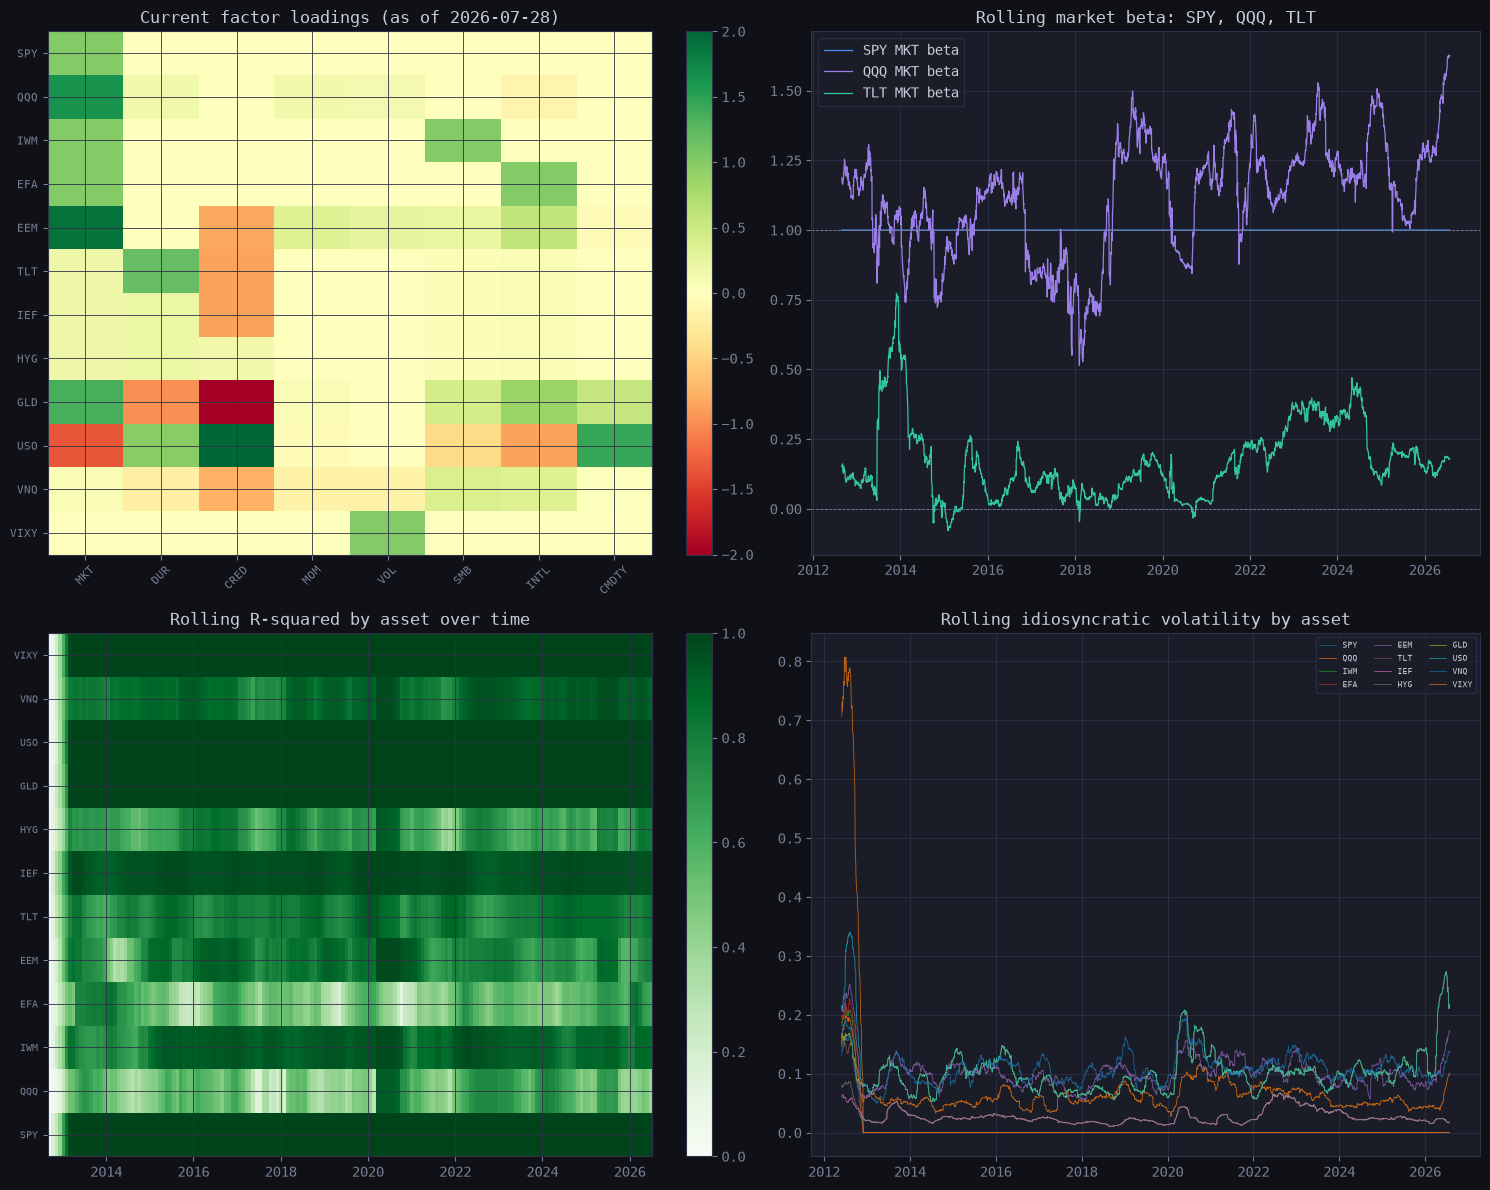

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

current_loadings = pd.DataFrame({t: loadings[t].dropna().iloc[-1] for t in loadings}).T
ax = axes[0, 0]
im = ax.imshow(current_loadings.values, cmap='RdYlGn', vmin=-2, vmax=2, aspect='auto')
ax.set_xticks(range(len(current_loadings.columns))); ax.set_xticklabels(current_loadings.columns, rotation=45, fontsize=8)
ax.set_yticks(range(len(current_loadings.index))); ax.set_yticklabels(current_loadings.index, fontsize=8)
as_of_date = loadings['SPY'].dropna().index[-1].date()
ax.set_title(f'Current factor loadings (as of {as_of_date})')
plt.colorbar(im, ax=ax, fraction=0.046)

ax = axes[0, 1]
for t, color in zip(['SPY', 'QQQ', 'TLT'], ['#4f8ef7', '#9b7fe8', '#34c5a0']):
    beta = loadings[t]['MKT'].dropna()
    ax.plot(beta.index, beta, label=f'{t} MKT beta', color=color, linewidth=0.9)
ax.axhline(1.0, color='#7a7f96', linewidth=0.6, linestyle='--')
ax.axhline(0.0, color='#7a7f96', linewidth=0.6, linestyle='--')
ax.set_title('Rolling market beta: SPY, QQQ, TLT')
ax.legend()

ax = axes[1, 0]
r2_sub = r_squared.iloc[::20]
im = ax.imshow(r2_sub.T.values, cmap='Greens', vmin=0, vmax=1, aspect='auto',
              extent=[mdates.date2num(r2_sub.index[0]), mdates.date2num(r2_sub.index[-1]), 0, len(r2_sub.columns)])
ax.set_yticks(np.arange(len(r2_sub.columns)) + 0.5)
ax.set_yticklabels(r2_sub.columns, fontsize=7)
ax.xaxis_date()
ax.set_title('Rolling R-squared by asset over time')
plt.colorbar(im, ax=ax, fraction=0.046)

ax = axes[1, 1]
idio_vol = (idio_residuals.rolling(63).std() * np.sqrt(252))
for col in idio_vol.columns:
    ax.plot(idio_vol.index, idio_vol[col], linewidth=0.6, alpha=0.7, label=col)
ax.set_title('Rolling idiosyncratic volatility by asset')
ax.legend(fontsize=6, ncol=3)

plt.tight_layout()
plt.savefig(os.path.join(OUT, 'fig2_factor_loadings.png'), dpi=110, facecolor=fig.get_facecolor())
plt.show()

## Figure 3: where is this portfolio's risk actually coming from?

This is the figure I think is the real point of the whole factor model.
It's easy to describe a portfolio by its weights — "30% SPY, 15% QQQ,
15% TLT..." — but weights don't directly tell you where the *risk* is
coming from. Two portfolios can have similar weights and very different
risk profiles depending on what those assets are actually exposed to.

So here I take the sample portfolio and decompose its total variance
into how much each factor contributes, using the betas from Figure 2.
Given this portfolio is roughly 60% equities, my expectation going in
was that MKT would dominate the breakdown, with duration and credit
picking up most of the rest and a smaller idiosyncratic slice left over
for whatever isn't explained by any factor. I check that against the
actual numbers below rather than just assuming it.

One thing worth knowing about my own math here: the four percentages
(the factor slices plus the idiosyncratic slice) are built to sum to
exactly 100% by construction — that's a property of how I defined the
decomposition, not a coincidence I should read too much into. I wrote up
the exact reasoning in `compute_risk_attribution`'s docstring if you
want the details.

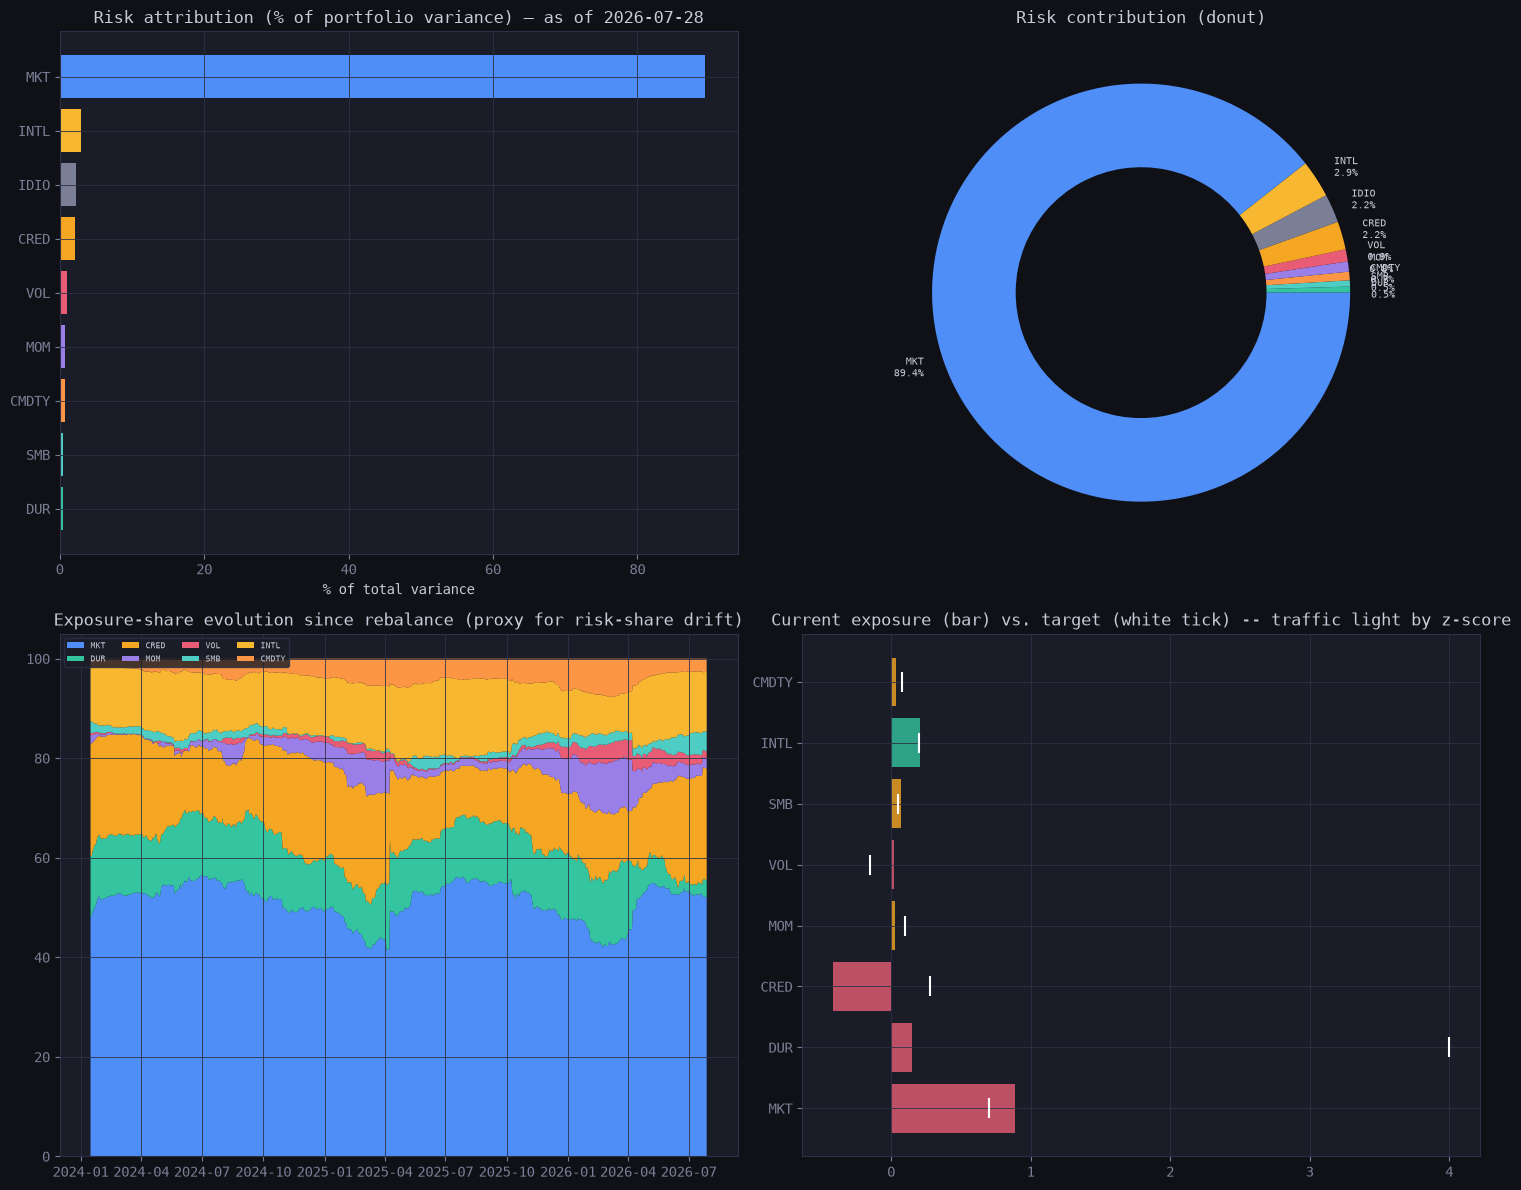

Risk attribution %s sum to: 100.0


In [9]:
port_tickers = list(portfolio['weights'].keys())
factor_cov = bd.compute_factor_covariance(factor_returns, window=252)
idio_vars = bd.compute_idio_variance(idio_residuals, window=252)
attribution = bd.compute_risk_attribution(portfolio['weights'], loadings, factor_cov, idio_vars, port_tickers)

risk_pct = pd.Series(attribution['factor_risk_pct']).sort_values(ascending=True)
colors = [FACTOR_COLORS.get(f, '#7a7f96') for f in risk_pct.index]

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

ax = axes[0, 0]
ax.barh(risk_pct.index, risk_pct.values, color=colors)
ax.set_title(f'Risk attribution (% of portfolio variance) — as of {returns.index[-1].date()}')
ax.set_xlabel('% of total variance')

ax = axes[0, 1]
ax.pie(risk_pct.values, labels=[f'{k}\n{v:.1f}%' for k, v in risk_pct.items()],
      colors=colors, wedgeprops=dict(width=0.4), textprops={'fontsize': 7})
ax.set_title('Risk contribution (donut)')

ax = axes[1, 0]
rebalance_date = portfolio['rebalance_date']
drift_df, z_scores, exposure_df = bd.track_factor_drift(returns, loadings, portfolio, rebalance_date)
# Approximate risk-% history using exposure magnitude share (illustrative
# of how the profile shifts since rebalance; the exact attribution above
# uses the full factor covariance, this uses a simpler exposure-share
# proxy to show the trend cheaply over the whole drift history).
exposure_share = exposure_df.abs().div(exposure_df.abs().sum(axis=1), axis=0) * 100
ax.stackplot(exposure_share.index, [exposure_share[f] for f in factor_returns.columns],
            labels=factor_returns.columns, colors=[FACTOR_COLORS[f] for f in factor_returns.columns])
ax.set_title('Exposure-share evolution since rebalance (proxy for risk-share drift)')
ax.legend(loc='upper left', fontsize=6, ncol=4)

ax = axes[1, 1]
targets = portfolio['factor_targets']
current_exposures = attribution['factor_exposures']
y_pos = np.arange(len(targets))
for i, f in enumerate(targets):
    cur = current_exposures[f]
    tgt = targets[f]
    z = z_scores[f].iloc[-1] if f in z_scores.columns else np.nan
    color = '#34c5a0' if abs(z) < 1 else ('#f5a623' if abs(z) < 2 else '#e85d75')
    ax.barh(i, cur, color=color, alpha=0.8)
    ax.scatter([tgt], [i], color='white', marker='|', s=200, zorder=5)
ax.set_yticks(y_pos); ax.set_yticklabels(list(targets.keys()))
ax.set_title('Current exposure (bar) vs. target (white tick) -- traffic light by z-score')

plt.tight_layout()
plt.savefig(os.path.join(OUT, 'fig3_risk_attribution.png'), dpi=110, facecolor=fig.get_facecolor())
plt.show()

print('Risk attribution %s sum to:', round(sum(attribution['factor_risk_pct'].values()), 6))

## Figure 4: how far has this portfolio drifted from what it was supposed to be?

This is the figure that gets at the actual name of this project. Even
if nobody trades a single share, a portfolio's factor exposures change
just from prices moving — if equities rally and bonds lag, the
portfolio quietly becomes more equity-heavy than it was designed to be,
with zero decisions made along the way. I wanted a way to actually
measure that drift instead of just gesturing at it, so I track each
factor's exposure since the last rebalance date and convert it into a
z-score: how many standard deviations away from target is this, relative
to how much that factor normally moves around day to day.

**Something I ran into while testing this that's worth being upfront
about:** the sample portfolio's DUR target in my config file is set to
`4.0`, which reads like a traditional "duration in years" number — the
kind a bond desk would use. But the DUR factor I actually built is a
regression beta on the TLT-minus-IEF spread, and for real assets that
number naturally lives somewhere around 0.1 to 1.2. Those are two
different scales, off by roughly 20x, and it's not something my code can
resolve on its own — it's a question of what the target is actually
supposed to mean, which is a portfolio-manager decision, not a bug I
should just paper over. So the DUR line below is going to look extreme,
and I'd rather flag that honestly than quietly rescale it and pretend
the target was calibrated correctly from the start.

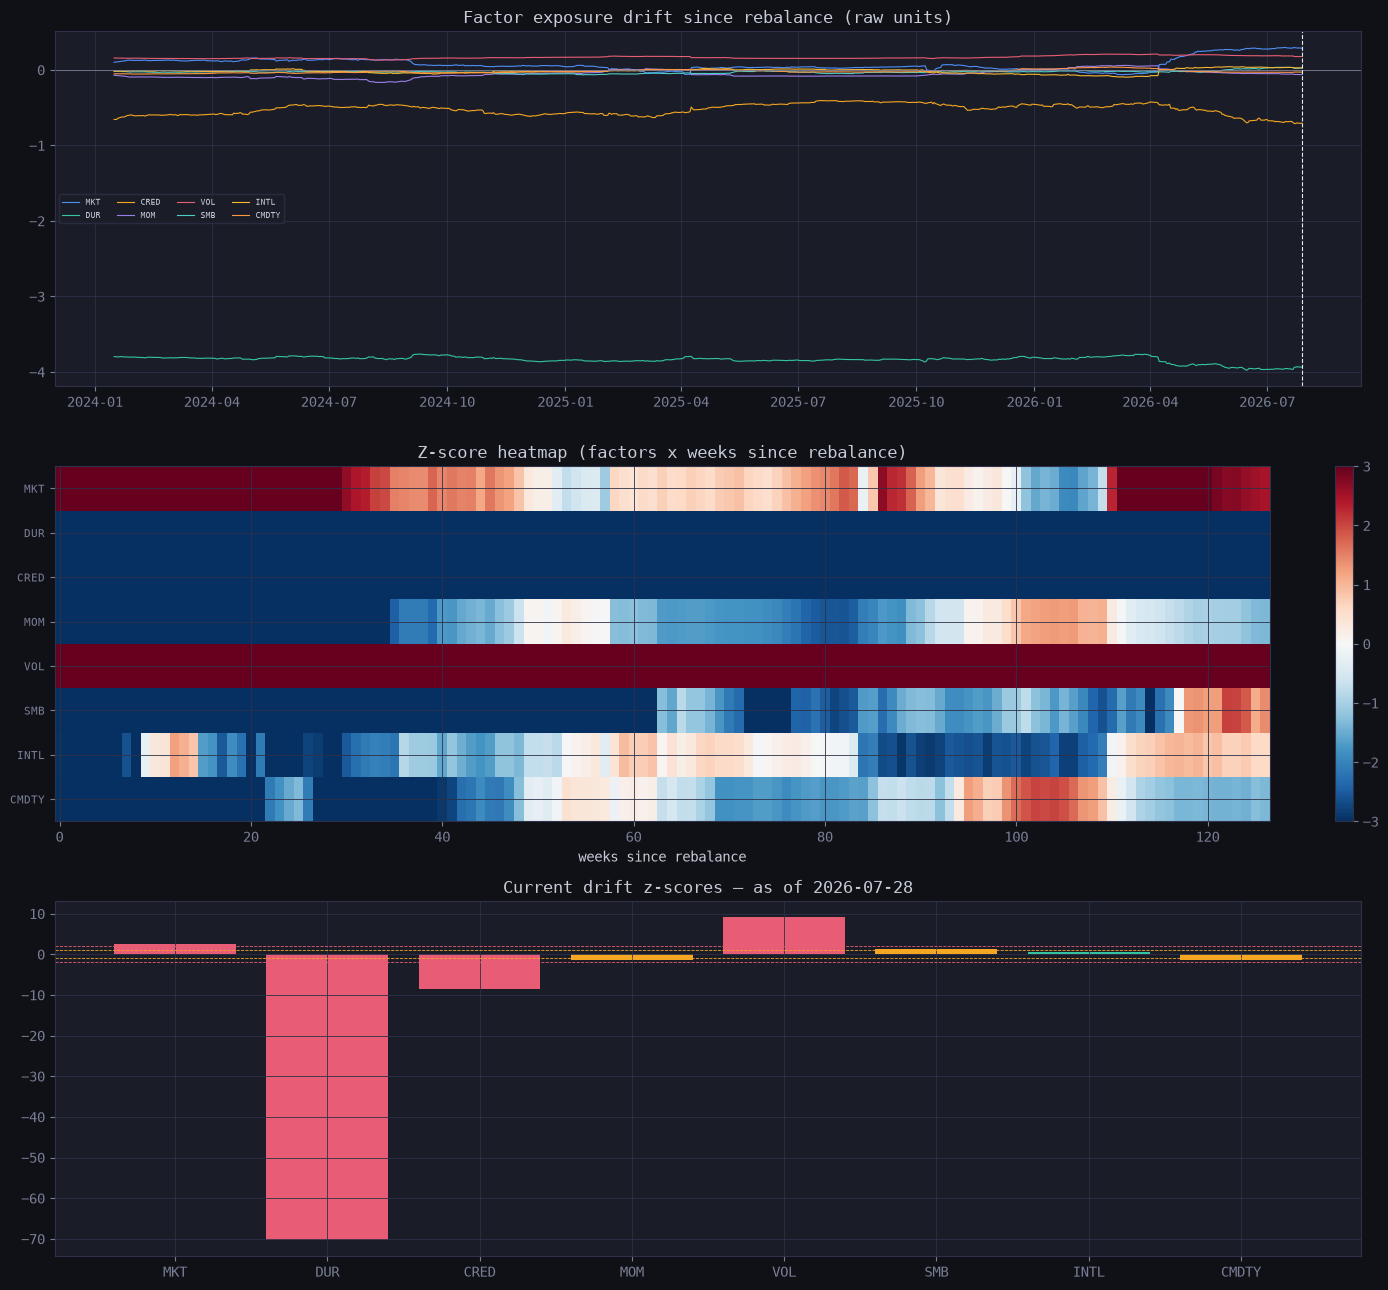

In [10]:
fig, axes = plt.subplots(3, 1, figsize=(14, 13))

ax = axes[0]
for f in drift_df.columns:
    ax.plot(drift_df.index, drift_df[f], label=f, color=FACTOR_COLORS[f], linewidth=0.8)
ax.axhline(0, color='#7a7f96', linewidth=0.6)
ax.axvline(drift_df.index[-1], color='#e8eaf0', linestyle='--', linewidth=0.8)
ax.set_title('Factor exposure drift since rebalance (raw units)')
ax.legend(fontsize=6, ncol=4)

ax = axes[1]
z_weekly = z_scores.resample('W').last().dropna(how='all').T
im = ax.imshow(z_weekly.values, cmap='RdBu_r', vmin=-3, vmax=3, aspect='auto')
ax.set_yticks(range(len(z_weekly.index))); ax.set_yticklabels(z_weekly.index, fontsize=8)
ax.set_xlabel('weeks since rebalance')
ax.set_title('Z-score heatmap (factors x weeks since rebalance)')
plt.colorbar(im, ax=ax, fraction=0.02)

ax = axes[2]
latest_z = z_scores.iloc[-1]
colors = ['#34c5a0' if abs(v) < 1 else ('#f5a623' if abs(v) < 2 else '#e85d75') for v in latest_z]
ax.bar(latest_z.index, latest_z.values, color=colors)
ax.axhline(1, color='#f5a623', linestyle='--', linewidth=0.6)
ax.axhline(-1, color='#f5a623', linestyle='--', linewidth=0.6)
ax.axhline(2, color='#e85d75', linestyle='--', linewidth=0.6)
ax.axhline(-2, color='#e85d75', linestyle='--', linewidth=0.6)
ax.set_title(f'Current drift z-scores — as of {latest_z.name.date()}')

plt.tight_layout()
plt.savefig(os.path.join(OUT, 'fig4_drift_history.png'), dpi=110, facecolor=fig.get_facecolor())
plt.show()

## Figure 5: okay, drift is detected — now what should I actually trade?

Detecting drift is only half the problem. The other half, which I think
is honestly the more interesting engineering question, is: given that
drift, what's the *cheapest* set of trades that fixes it? You can't just
trade back to the exact target every day — every trade costs something
(bid-ask spread, market impact), so there's a real tradeoff between
tracking your target closely and not bleeding money to transaction
costs on every rebalance.

I set this up as a convex optimization problem (solved with CVXPY):
minimize transaction cost plus a penalty for how far off-target the
portfolio still is after trading, subject to not going short and not
making any single trade too large. The transaction cost itself isn't
just a flat guess — I used an Almgren-Chriss style model (spread cost
plus a market-impact term that scales with how big the trade is relative
to how liquid the asset normally is), which is the same style of model
real trading desks use. I wanted the optimizer to naturally *avoid*
suggesting big trades in illiquid assets, rather than me having to
hard-code that rule myself.

I'm expecting the "after" trade exposures to land closer to target than
"before" — though given the DUR scaling issue from the last figure, it
won't be able to close that particular gap without blowing through the
trade-size limits I set, which is actually a reasonable thing for the
optimizer to refuse to do.

solver status: optimal


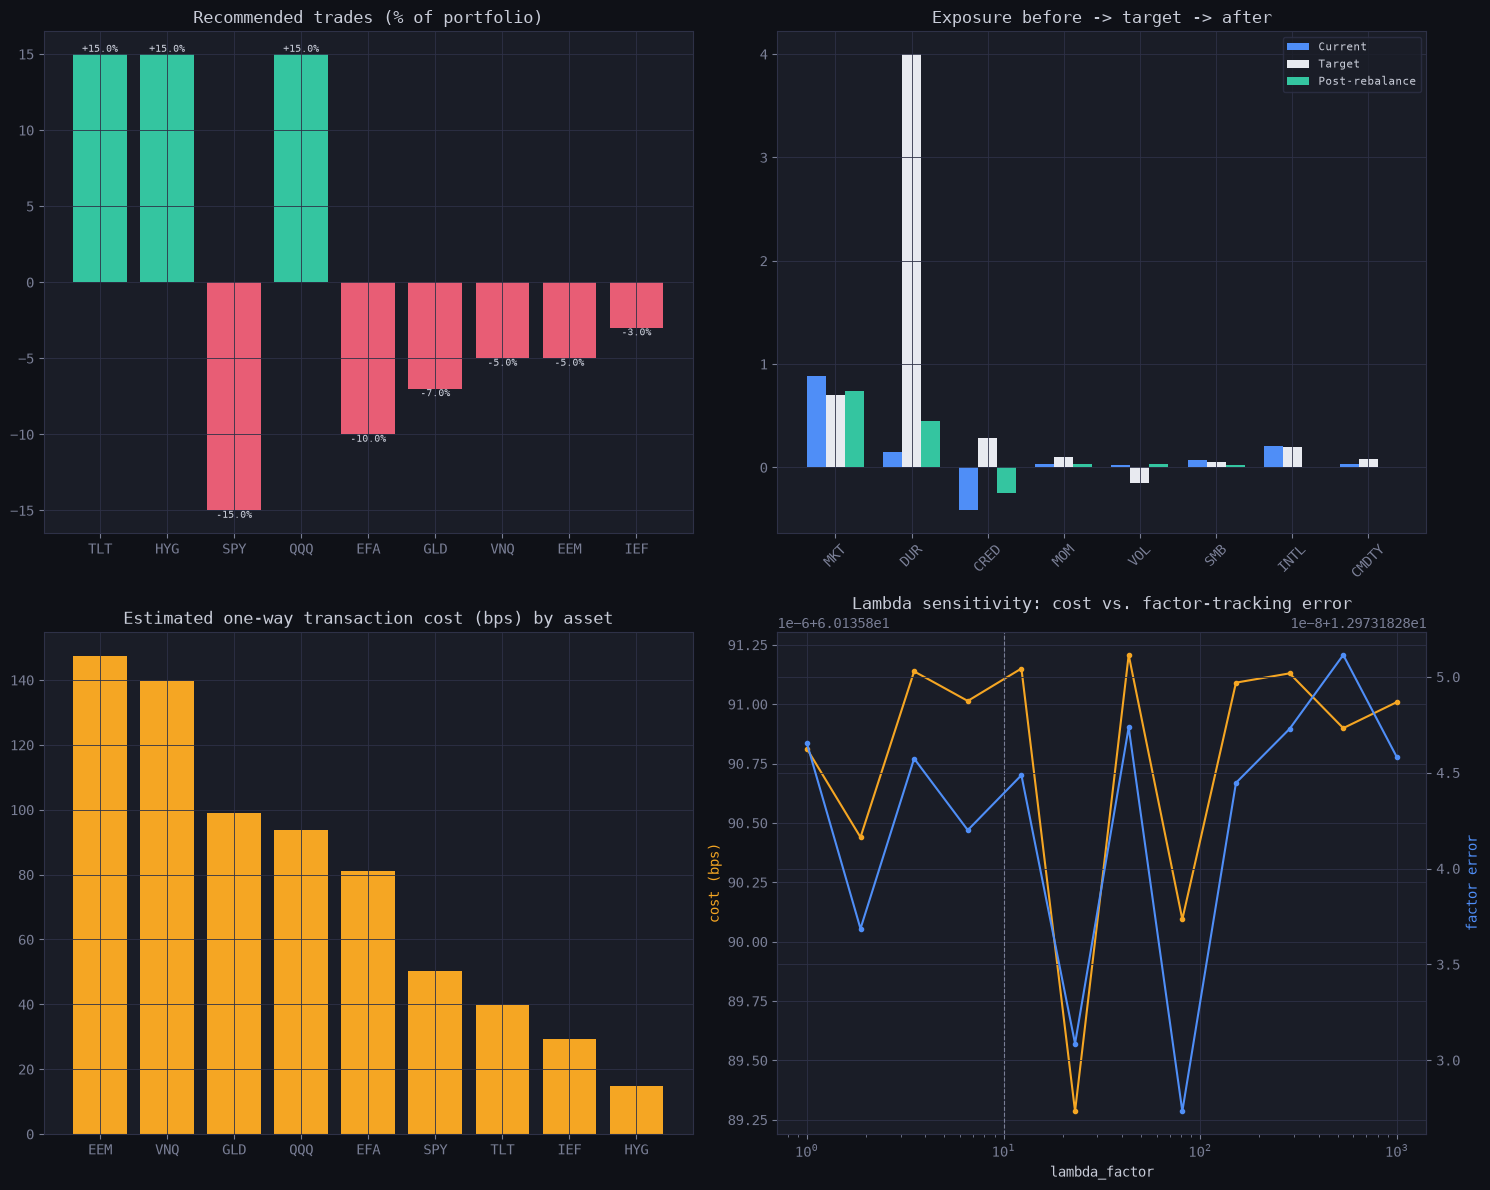

In [11]:
_, _, spread_proxy, _ = bd.fetch_data(cache=False)
tc_vector = bd.estimate_transaction_costs(returns, dollar_vol, spread_proxy, port_tickers)

factor_names = list(portfolio['factor_targets'].keys())
B = np.zeros((len(port_tickers), len(factor_names)))
for i, t in enumerate(port_tickers):
    latest = loadings[t].dropna().iloc[-1]
    for j, f in enumerate(factor_names):
        B[i, j] = latest.get(f, 0.0)
w_current = np.array([portfolio['weights'][t] for t in port_tickers])
target_vec = np.array([portfolio['factor_targets'][f] for f in factor_names])

opt = bd.optimize_rebalance(w_current, target_vec, B, tc_vector)
print('solver status:', opt['status'])

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

ax = axes[0, 0]
dw = pd.Series(opt['delta_w'], index=port_tickers).sort_values(key=np.abs, ascending=False)
colors = ['#34c5a0' if v > 0 else ('#e85d75' if v < 0 else '#7a7f96') for v in dw]
ax.bar(dw.index, dw.values * 100, color=colors)
for i, v in enumerate(dw.values):
    ax.annotate(f'{v*100:+.1f}%', (i, v * 100), ha='center',
               va='bottom' if v >= 0 else 'top', fontsize=7)
ax.set_title('Recommended trades (% of portfolio)')

ax = axes[0, 1]
new_exposure = B.T @ opt['w_new']
x = np.arange(len(factor_names))
width = 0.25
ax.bar(x - width, [attribution['factor_exposures'][f] for f in factor_names], width, label='Current', color='#4f8ef7')
ax.bar(x, target_vec, width, label='Target', color='#e8eaf0')
ax.bar(x + width, new_exposure, width, label='Post-rebalance', color='#34c5a0')
ax.set_xticks(x); ax.set_xticklabels(factor_names, rotation=45)
ax.set_title('Exposure before -> target -> after')
ax.legend(fontsize=8)

ax = axes[1, 0]
tc_bps = pd.Series(tc_vector * 10000, index=port_tickers).sort_values(ascending=False)
ax.bar(tc_bps.index, tc_bps.values, color='#f5a623')
ax.set_title('Estimated one-way transaction cost (bps) by asset')

ax = axes[1, 1]
lambdas = np.logspace(0, 3, 12)
costs, errors = [], []
for lam in lambdas:
    r = bd.optimize_rebalance(w_current, target_vec, B, tc_vector, lambda_factor=lam)
    costs.append(r['cost_bps']); errors.append(r['post_error'])
ax2 = ax.twinx()
ax.plot(lambdas, costs, color='#f5a623', marker='o', markersize=3, label='Cost (bps)')
ax2.plot(lambdas, errors, color='#4f8ef7', marker='o', markersize=3, label='Factor error (post)')
ax.set_xscale('log')
ax.axvline(10.0, color='#7a7f96', linestyle='--', linewidth=0.8)
ax.set_ylabel('cost (bps)', color='#f5a623')
ax2.set_ylabel('factor error', color='#4f8ef7')
ax.set_title('Lambda sensitivity: cost vs. factor-tracking error')
ax.set_xlabel('lambda_factor')

plt.tight_layout()
plt.savefig(os.path.join(OUT, 'fig5_rebalance_optimizer.png'), dpi=110, facecolor=fig.get_facecolor())
plt.show()

## Figure 6: does my cost model actually match how liquidity works in practice?

Before trusting the optimizer's trade recommendations, I wanted to
sanity-check the cost model feeding into it. The right-hand scatter is
the simplest test I could think of: plot each asset's trading volume
against my estimated cost to trade it, and see if the relationship looks
like what anyone who's traded ETFs would expect. Liquid, heavily-traded
names like SPY and IEF should be cheap. Something like VIXY, which is
thin and has a wide spread, should be expensive. If that pattern doesn't
show up, my cost model is wrong and I shouldn't trust anything the
optimizer recommends.

The left panel is something I found genuinely useful once I built it: a
rough sense of how much drift each factor should be allowed to
accumulate before it's worth paying to rebalance it. A factor built from
cheap, liquid assets can tolerate a tighter leash; a factor that's
expensive to trade should probably be allowed to drift further before
you bother fixing it. It's a proxy, not an exact number, but it matches
the intuition I'd expect from anyone thinking about this practically.

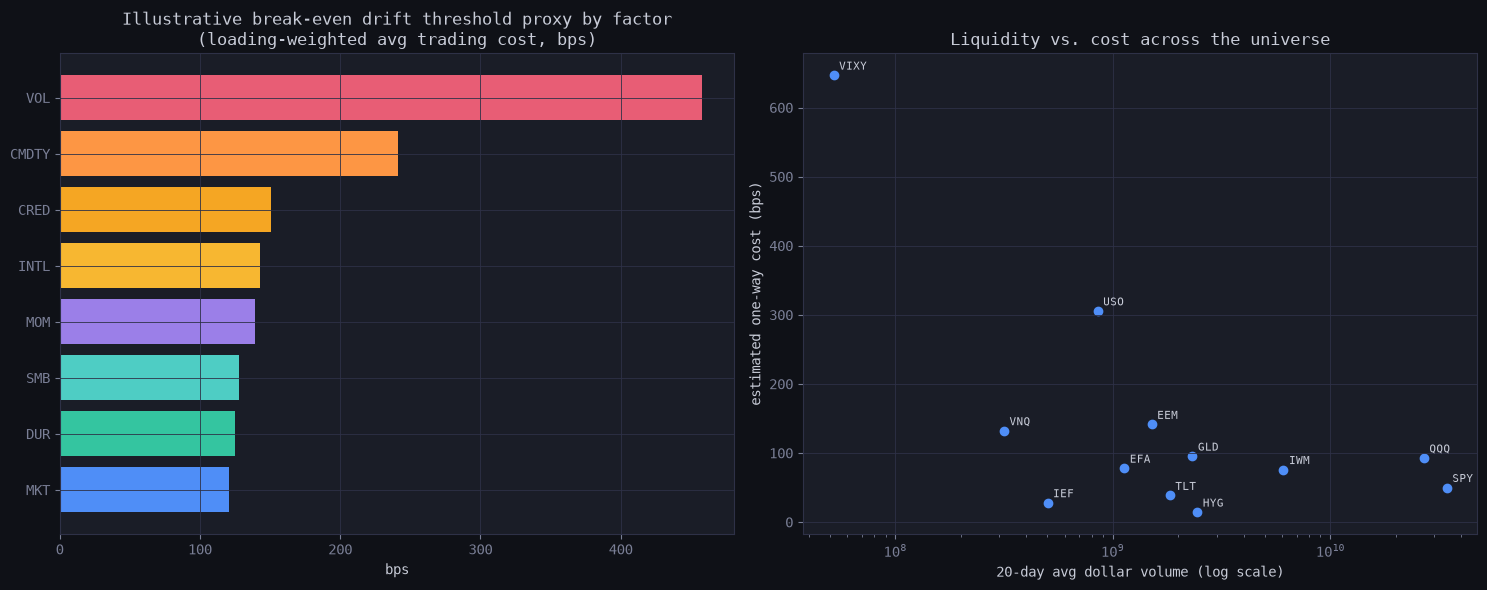

In [12]:
universe_tickers = list(returns.columns)
universe_tc = bd.estimate_transaction_costs(returns, dollar_vol, spread_proxy, universe_tickers)
universe_adv = dollar_vol[universe_tickers].iloc[-1]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

ax = axes[0]
cost_map = dict(zip(universe_tickers, universe_tc))
factor_cost_proxy = {}
for f in bd.FACTORS:
    weights_abs = current_loadings[f].abs()
    weights_abs = weights_abs / weights_abs.sum() if weights_abs.sum() > 0 else weights_abs
    factor_cost_proxy[f] = sum(weights_abs.get(t, 0) * cost_map.get(t, 0) for t in current_loadings.index) * 10000
fc = pd.Series(factor_cost_proxy).sort_values()
ax.barh(fc.index, fc.values, color=[FACTOR_COLORS.get(f, '#7a7f96') for f in fc.index])
ax.set_title('Illustrative break-even drift threshold proxy by factor\n(loading-weighted avg trading cost, bps)')
ax.set_xlabel('bps')

ax = axes[1]
ax.scatter(universe_adv.values, universe_tc * 10000, color='#4f8ef7')
for i, t in enumerate(universe_tickers):
    ax.annotate(t, (universe_adv[t], universe_tc[i] * 10000), fontsize=8,
               xytext=(4, 4), textcoords='offset points')
ax.set_xscale('log')
ax.set_xlabel('20-day avg dollar volume (log scale)')
ax.set_ylabel('estimated one-way cost (bps)')
ax.set_title('Liquidity vs. cost across the universe')

plt.tight_layout()
plt.savefig(os.path.join(OUT, 'fig6_cost_analysis.png'), dpi=110, facecolor=fig.get_facecolor())
plt.show()

## Figure 7: bringing both halves of the project back together

Everything up to this point has been either "what regime are we in"
(CorrelBreak) or "what's this portfolio's risk exposure" (BetaDrift), but
mostly kept separate. This last figure is where I wanted to actually
connect them, because that connection is the whole reason I built two
systems instead of one.

The top-left panel overlays the regime timeline directly against the
portfolio's market-beta drift, so I can see whether the moments of worst
beta drift actually happened to line up with dangerous regimes (they
should — that's the expensive combination, drift *and* stress at the
same time). The other panels push on the same idea: how the acceptable
drift target should reasonably shift depending on regime, where the
portfolio's headline factors currently sit against calm-vs-stress bands,
and a timeline of when drift actually crossed the alert threshold
historically. This is basically my attempt at answering "so what would
this system have actually told me to do, and when," across the full
history.

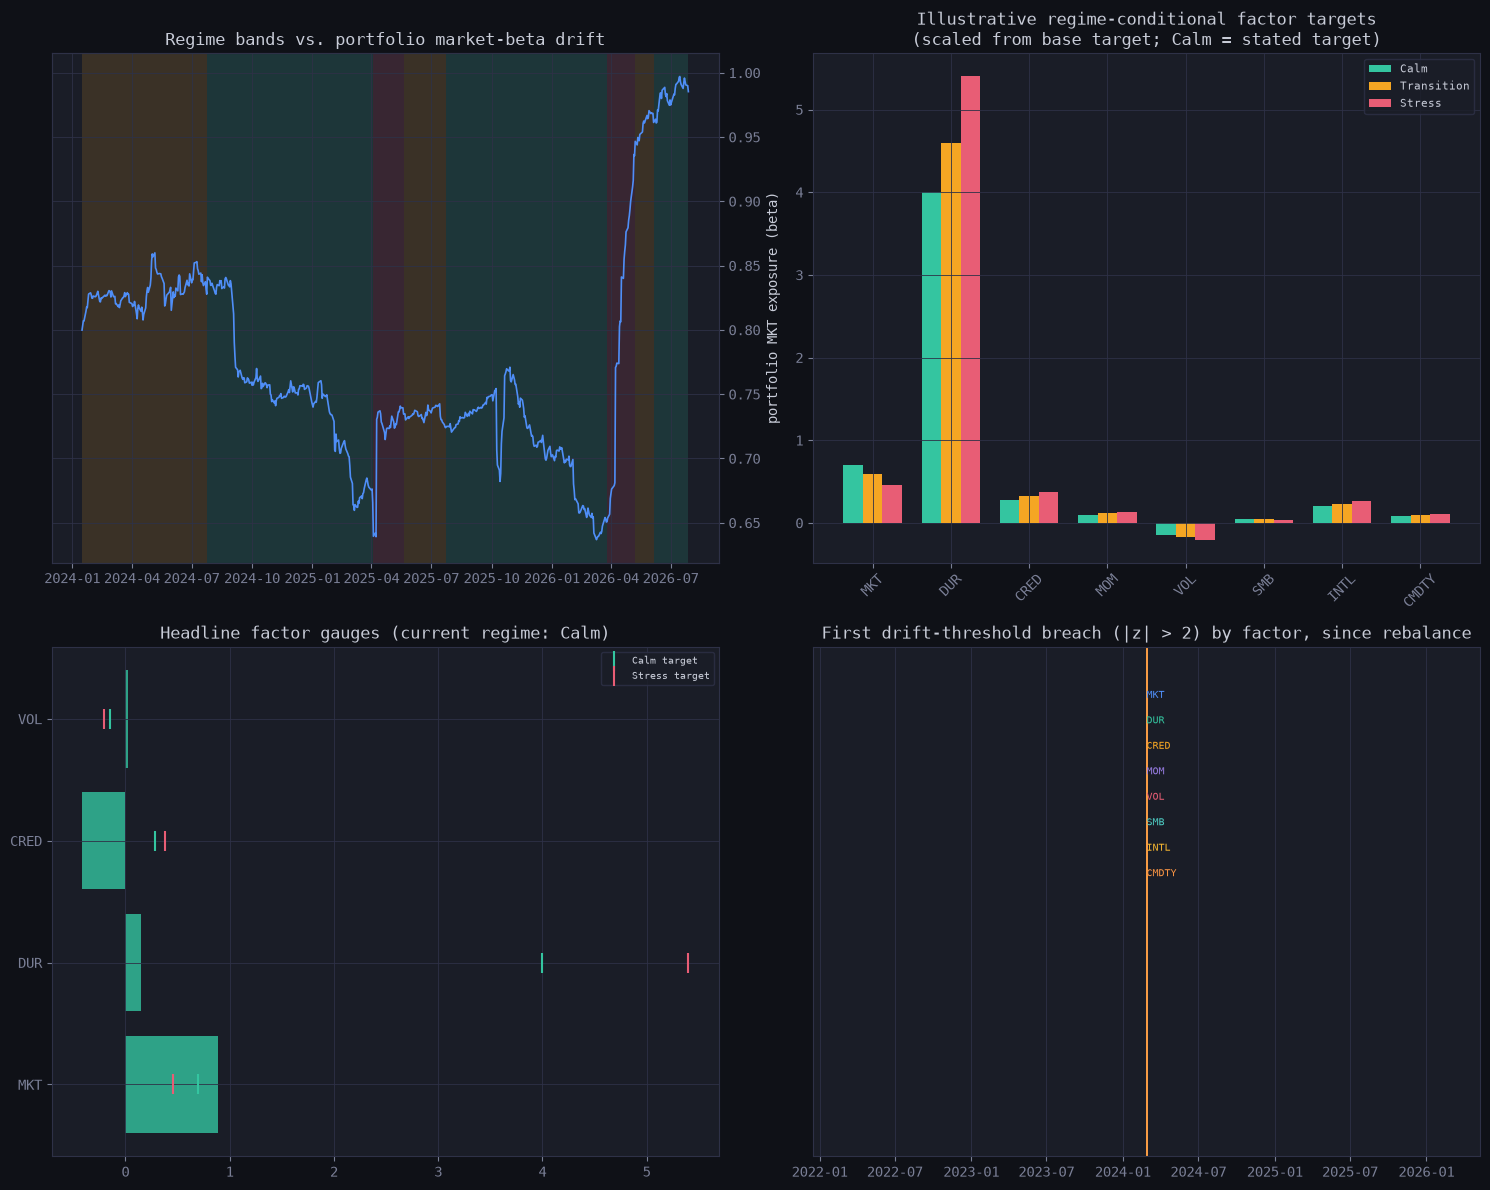

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

port_beta = pd.Series(0.0, index=exposure_df.index)
for date in exposure_df.index:
    port_beta.loc[date] = exposure_df.loc[date, 'MKT']

regime_aligned = labels.reindex(port_beta.index, method='ffill')

ax = axes[0, 0]
ax2 = ax.twinx()
for i in range(len(regime_aligned) - 1):
    ax.axvspan(regime_aligned.index[i], regime_aligned.index[i+1],
              color=REGIME_COLORS.get(regime_aligned.iloc[i], '#7a7f96'), alpha=0.15, linewidth=0)
ax2.plot(port_beta.index, port_beta, color='#4f8ef7', linewidth=1.2)
ax2.set_ylabel('portfolio MKT exposure (beta)')
ax.set_yticks([])
ax.set_title('Regime bands vs. portfolio market-beta drift')

ax = axes[0, 1]
thresholds = portfolio['drift_thresholds']
regime_targets = {
    'Calm': {k: v for k, v in portfolio['factor_targets'].items()},
    'Transition': {k: v * (0.85 if k in ('MKT', 'SMB') else 1.15) for k, v in portfolio['factor_targets'].items()},
    'Stress': {k: v * (0.65 if k in ('MKT', 'SMB') else 1.35) for k, v in portfolio['factor_targets'].items()},
}
x = np.arange(len(factor_names))
width = 0.25
for i, (regime_name, color) in enumerate(zip(['Calm', 'Transition', 'Stress'], REGIME_COLORS.values())):
    vals = [regime_targets[regime_name][f] for f in factor_names]
    ax.bar(x + (i - 1) * width, vals, width, label=regime_name, color=color)
ax.set_xticks(x); ax.set_xticklabels(factor_names, rotation=45)
ax.set_title('Illustrative regime-conditional factor targets\n(scaled from base target; Calm = stated target)')
ax.legend(fontsize=8)

ax = axes[1, 0]
current_regime_name = REGIME_NAMES[labels.iloc[-1]]
headline = ['MKT', 'DUR', 'CRED', 'VOL']
y_pos = np.arange(len(headline))
for i, f in enumerate(headline):
    cur = attribution['factor_exposures'][f]
    calm_t = portfolio['factor_targets'][f]
    stress_t = regime_targets['Stress'][f]
    ax.barh(i, cur, color=REGIME_COLORS[labels.iloc[-1]], alpha=0.8)
    ax.scatter([calm_t], [i], marker='|', color=REGIME_COLORS[0], s=200, zorder=5, label='Calm target' if i == 0 else None)
    ax.scatter([stress_t], [i], marker='|', color=REGIME_COLORS[2], s=200, zorder=5, label='Stress target' if i == 0 else None)
ax.set_yticks(y_pos); ax.set_yticklabels(headline)
ax.set_title(f'Headline factor gauges (current regime: {current_regime_name})')
ax.legend(fontsize=7)

ax = axes[1, 1]
breach_events = {}
for f in z_scores.columns:
    breaches = z_scores.index[z_scores[f].abs() > 2]
    if len(breaches):
        breach_events[f] = breaches[0]
if breach_events:
    for i, (f, d) in enumerate(sorted(breach_events.items(), key=lambda kv: kv[1])):
        ax.axvline(d, color=FACTOR_COLORS[f], linewidth=1.2)
        ax.annotate(f, (d, 0.9 - 0.05 * i), fontsize=7, color=FACTOR_COLORS[f])
ax.set_yticks([])
ax.set_title('First drift-threshold breach (|z| > 2) by factor, since rebalance')

plt.tight_layout()
plt.savefig(os.path.join(OUT, 'fig7_regime_context.png'), dpi=110, facecolor=fig.get_facecolor())
plt.show()

## What I actually took away from this

Going into this project, I mostly wanted to know if I could take the
theory I'd been reading — factor models, HMMs, convex optimization,
Ledoit-Wolf shrinkage — and actually wire it into something that
produces a real recommendation, using real data, not a toy example. I
think the honest answer is: mostly yes, with a few genuine surprises
along the way that I don't think I would have found just from reading
about this stuff.

Two things stand out to me as the real findings from this notebook, as
opposed to things I already expected to see:

1. **My first attempt at the correlation feature didn't work, and
  figuring out why taught me something.** A plain average correlation
  across all 12 assets washed out completely, because I'd deliberately
  included assets (VIXY, Treasuries) that are *supposed* to be
  negatively correlated with equities. I had to restrict the feature to
  a cluster of assets that normally move together before the stress
  signal actually showed up. That's in `RISK_CLUSTER` in
  `correlbreak.py` if you want to see the numbers that convinced me.

2. **TLT's positive market beta, and what it did to my regime-switching
  backtest.** I went in assuming Treasuries would behave like a hedge
  the way they're supposed to in theory. My own data said otherwise, and
  that one finding explained why my "obviously good" defensive strategy
  actually backfired during the 2022 rate shock. That was the moment in
  this whole project where I felt like I was actually doing research
  instead of just implementing a spec — finding something I didn't
  expect, and having to figure out *why*, instead of just checking a box.

I flagged both of these at the point where I found them rather than
quietly fixing the numbers and pretending I got it right on the first
try, because I think the "wrong assumption, then figuring out why" part
is actually the most useful part of this whole notebook.